In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI # thư viện chính để sử dụng Google Generative AI
from dotenv import find_dotenv, load_dotenv # thư viện để load biến môi trường từ file .env
from langchain_core.prompts import (
    HumanMessagePromptTemplate,
    ChatPromptTemplate
) # phục vụ cho việc tạo prompt
from pydantic import BaseModel, Field # thư viện để định nghĩa kiểu dữ liệu
from langchain_core.output_parsers import PydanticOutputParser # thư viện để phân tích đầu ra từ mô hình
from typing import Optional # Giúp xử lí các kiểu dữ liệu tùy chọn, ví dụ Optional[str] có thể là str hoặc None
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import pandas as pd
import getpass
import time
import json
import warnings
import concurrent.futures
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type
import random

In [2]:
#Bỏ qua cảnh báo FutureWarning
warnings.simplefilter(action='ignore', category=FutureWarning)

# GIAI ĐOẠN 1: TẠO PROMPT VÀ ĐIỀU CHỈNH NỘI DUNG PHÙ HỢP, ÁP DỤNG CÁC KĨ THUẬT ONE-SHOT VÀ FEW-SHOT PROMPTING


In [3]:
#  NHÓM 1: THÔNG TIN CƠ BẢN 
class JobGeneralInfo(BaseModel):
    #Lấy tên công việc
    Job_Title: Optional[str] = Field(default = "",description="Lấy đầy đủ tên công việc, chính xác từng chữ trong yêu cầu tuyển dụng, chỉ lấy thông tin liên quan đến tên công việc, tuyệt đối không đưa các thông tin liên quan đến các nội dung sau vào mục job_title:" \
        "Số năm kinh nghiệm, " \
        "Mức lương hay thông tin về thưởng thêm, phụ cấp, " \
        "Ngoại ngữ yêu cầu ví dụ như tiếng Anh, tiếng Trung,... " \
        "Địa điểm, thành phố, quốc gia, tuyển dụng ví dụ như Hồ Chí Minh,... " \
        "Thông tin về ngày nghỉ, ngày làm việc trong tuần (ví dụ Nghỉ Thứ 7 - Chủ Nhật) (Sử dụng thông tin ngày nghỉ này để điền cho các trường liên quan đến việc có đi làm thứ 7 hay Chủ Nhật không), " \
        "Ngoài các thông tin trên, hãy giữ lại đầy đủ tên công việc và thông tin liên quan đến vị trí công việc đó, ví dụ: Senior BA (Gaming/Social/Metaverse) thì vẫn giữ là Senior BA (Gaming/Social/Metaverse)" \
        "Sau đó, viết hoa chữ cái đầu tiếng Việt, tiếng Anh thì viết hoa tên công việc, ví dụ: lập trình viên backend Developer (Golang Từ 2 Năm Kinh Nghiệm, 20 - 25 Triệu/Tháng, Tiếng Anh, Hồ Chí Minh, Nghỉ Thứ 7 - Chủ Nhật, Thu Nhập Hấp Dẫn) chuyển thành duy nhất thông tin liên quan đến nghề nghiệp và chuyên môn là: Lập trình viên Backend Developer")

    #Lấy tất cả Tech Stack
    Tech_Stack: Optional[list] = Field(default =[""],description=r"""Dựa vào 'job_description' và 'job_requirements' để lấy chính xác, nhất quán tên chính thức của tất cả các Tech Stack, tên các thuật ngữ chuyên môn được yêu cầu (Mobile, Web, Docker,Database Management System,...) và các công nghệ, phương pháp lập trình OOP, skills, tools, môn học như toán (Đại Số, Xác Suất Thống Kê), hệ quản trị cơ sở dữ liệu như MySQL, SQL Sever,PostgreSQL, vân vân... (nếu có), không điền ngôn ngữ truy vấn SQL vào mục này vì nó thuộc mục 'Programming_Language'. Kết quả trả về dưới dạng chữ in hoa toàn bộ. Yêu cầu khi bạn trích ra tên các công nghệ thì hãy sử dụng tên nhất quán của công nghệ, nếu có nhiều tên gọi khác nhau thì hãy chọn 1 tên gọi chính thức nhất để trả về nhằm tạo độ nhất quán, tránh hiện tượng 1 công nghệ được gọi với nhiều tên khác nhau. Ví dụ, xem xét các dạng sau để thống nhất và trả về 1 key từ các biến thể là list các value, áp dụng tương tự cho các tech stack và skill khác:" \ 
    "AWS": ["AWS", "AMAZON WEB SERVICES", "AWS CLOUD", "AMAZON CLOUD"], \
    "SQL SERVER": ["SQL SERVER", "MSSQL", "MS SQL", "MICROSOFT SQL SERVER", "SQLSERVER", "SQL SEVER", "MS SQL SERVER", "MSSQLSERVER", "MS-SQL SERVER", "MS SQL DATABASE"],
    "POSTGRESQL : Postgre Sql" 
    "MYSQL": ["My SQL", "MySQL"], \
    "CI/CD": ["CI/CD", "CICD", "CI CD", "CONTINUOUS INTEGRATION", "CONTINUOUS DELIVERY", "CONTINUOUS DEPLOYMENT", "CI", "CI-CD", "CI CD PIPELINES", "CI CD PIPELINE", "CI/CT", "DEVOPS CI/CD"], \
    "DOCKER": ["DOCKER", "DOCKER CONTAINERS", "DOCKER CONTAINERIZATION", "DOCKER SWARM", "DOCKER KUBERNETES", "CONTAINERIZATION WITH DOCKER", "DOCKER IMAGES", "DOCKER HUB"]
    """)
    #Lấy tất cả tên ngôn ngữ lập trình/truy vấn
    Programming_Language: Optional[list] = Field(default =[""],description=r"""Dựa vào 'job_description' và 'job_requirements' để lấy chính xác, nhất quán tên chính thức của tất cả tên ngôn ngữ lập trình,ví dụ thông tin có đề cập đến việc sử dụng Python, C++, Java thì trả về đúng tên ngôn ngữ lập trình là PYTHON, C++, JAVA, tương tự với các ngôn ngữ lập trình khác, viết hoa toàn bộ chữ cái. Yêu cầu khi bạn trích ra tên các ngôn ngữ lập trình thì hãy sử dụng tên nhất quán của ngôn ngữ lập trình, nếu có nhiều tên gọi khác nhau thì hãy chọn 1 tên gọi chính thức nhất để trả về nhằm tạo độ nhất quán, tránh hiện tượng 1 ngôn ngữ lập trình được gọi với nhiều tên khác nhau. Ví dụ, xem xét các dạng sau để thống nhất và trả về 1 key từ các biến thể là list các value, áp dụng tương tự cho các ngôn ngữ lập trình và truy vấn khác: 
    "Python" : "PYTHON"
    "Java Script" : "JAVASCRIPT"
    "JS" : "JAVASCRIPT"
    "Type Script" : "TYPESCRIPT"
    "JAVASCRIPT": ["JAVASCRIPT", "JS", "ES5", "ES6", "ES6+"],
    "SQL": ["SQL", "PL/SQL", "PLSQL", "T-SQL", "MS SQL", "MSSQL", "MICROSOFT SQL SERVER", "POSTGRES", "POSTGRESQL", "ORACLE", "MYSQL", "MARIADB"],
    "REACT": ["REACT", "REACTJS", "REACT.JS", "REACTNATIVE", "REACT NATIVE", "REACT-NATIVE"],
    "VUE.JS": ["VUE", "VUEJS", "VUE.JS"],
    "REST API": ["REST API", "RESTFUL API", "REST APIS"],
    ".NET": [".NET", "NET", ".NETCORE", "NETCORE", ".NET CORE", "ASP.NET", "ASP.NET CORE", "ASP .NET"],
    "SPARK": ["SPARK", "PYSPARK"].
    "Nếu thông tin có đề cập đến các hệ quản trị cơ sở dữ liệu 'SQL' hoặc 'NoSQL' thì hãy suy luận ra và bổ sung thêm trong kết quả trả về. Ví dụ thông tin có đề cập đến SQL Sever thì thêm SQL vào kết quả trả về, nếu có đề cập MongoDB thì thêm NOSQL từ kết quả trả về, nếu có cả hai thì bổ sung cả hai vào kết quả trả về. Các Database Management System hay Hệ quản trị cơ sở dữ liệu ví dụ như PostgreSQL, SQL Sever, MySQL, vân vân.. nếu có trong Tech Stack được yêu cầu thì tuyệt đối không được trả về tên của hệ quản trị cơ sở dữ liệu mà chỉ trả về SQL hoặc là NOSQL để thể hiện ý nghĩa là ngôn ngữ truy vấn. Nếu không có thông tin thì trả về danh sách rỗng""")

    # Lấy tất cả các tên, vị trí chuyên môn được yêu cầu
    Roles: Optional[list] = Field(default = [""],description="Dựa vào tags_role để lấy chính xác tất cả tên, vị trí hay lĩnh vực chuyên môn được yêu cầu và đề cập trong thông tin, ví dụ: Backend Developer, Frontend Developer, DevOps Engineer, Data Scientist, AI Engineer, Mobile Developer, Game Developer, QA Engineer, Security Specialist, Cloud Engineer, Fullstack Developer, System Administrator, Database Administrator, Network Engineer, Software Architect, Technical Lead, Project Manager, Business Analyst, UI/UX Designer, Product Manager, Scrum Master, IT Support Specialist, Việc làm IT, và các vị trí hay lĩnh vực chuyên môn khác. Yêu cầu không được thêm bớt nội dung không liên quan, hãy trả về chính xác nội dung vị trí, lĩnh vực chuyên môn được đề cập đồng thời viết hoa toàn bộ kết quả trả về. Nếu không có thông tin về các vị trí chuyên môn trong yêu cầu tuyển dụng thì trả về giá trị là danh sách rỗng")
    
    #Lấy số lượng tuyển dụng
    Recruitment_Count : Optional[int] = Field(default = 1, description="Lấy chính xác số lượng tuyển dụng từ 'quantity', ví dụ 1,2, nếu không có thông tin thì trả về giá trị là 1")
    
    #Lấy tên tỉnh thành tuyển dụng
    Province: Optional[list] = Field(default = [""],description="Lấy chính xác tất cả tên tỉnh thành được đề cập trong địa điểm tuyển dụng là 'tags_location', kết quả trả về dưới dạng in hoa, ví dụ: HÀ NỘI, THÀNH PHỐ HỒ CHÍ MINH, hoặc nếu không có tỉnh thành cụ thể mà chỉ ghi là 'Nước ngoài' thì hãy trả kết quả về là 'NƯỚC NGOÀI'. Trả về giá trị là danh sách rỗng nếu không có thông tin về tỉnh thành trong yêu cầu tuyển dụng")
    
    # Lấy địa chỉ tên tỉnh thành của công ty
    Company_Location: Optional[list] = Field(default = [""],description="Dựa vào thông tin trong 'company_address' để lấy chính xác tất cả tên tỉnh thành nơi công ty đóng trụ sở, kết quả trả về dưới dạng danh sách in hoa, ví dụ: HÀ NỘI, HỒ CHÍ MINH, ĐÀ NẴNG. Nếu như không có tên tỉnh thành trong 'company_address' thì hãy dựa vào 'province' để lấy tên tỉnh thành nơi công ty đóng trụ sở. Chú ý định dạng trả về chỉ lấy tên của tỉnh thành, ví dụ Thành phố Hồ Chí Minh, Thành phố Đà Nẵng thì chỉ trả về là HỒ CHÍ MINH, ĐÀ NẴNG chứ không lấy thông tin phụ. Trả về giá trị là rỗng nếu không có thông tin về tỉnh thành trong 'company_address' và 'province'.")
    
    # Lấy số lượng nhân viên tối thiểu hiện có của công ty
    Current_Employee_Min : Optional[int] = Field(default = None, description="Dựa vào thông tin trong 'company_scale' để lấy chính xác số lượng nhân viên tối thiểu hiện có của công ty, ví dụ: nếu ghi là 50-100 nhân viên thì trả về giá trị là 50. Ví dụ nếu thông tin là 1000+ thì trả về giá trị là 1000. Nếu không có thông tin về số lượng nhân viên hiện có thì trả về giá trị là None")
    
    # Lấy số lượng nhân viên tối đa hiện có của công ty
    Current_Employee_Max : Optional[int] = Field(default = None, description="Dựa vào thông tin trong 'company_scale' để lấy chính xác số lượng nhân viên tối đa hiện có của công ty, ví dụ: nếu ghi là 50-100 nhân viên thì trả về giá trị là 100. Ví dụ nếu thông tin là 1000+ thì trả về giá trị là None. Nếu không có thông tin về số lượng nhân viên hiện có thì trả về giá trị là None") 
    
    #Lấy thông tin ngoại ngữ làm việc
    Language: Optional[list] = Field(default = [""], description="Dựa vào địa điểm nơi làm việc, xác định ngôn ngữ đầu tiên. Sau đó trích ra thêm các ngoại ngữ yêu cầu dựa vào 'job_description' và 'tags_skill' nếu nhà tuyển dụng có yêu cầu, bỏ các thông tin phụ về cấp độ, chú ý không dựa vào 'job_benefits' để lấy thông tin ngoại ngữ yêu cầu vì đây là nội dung về phúc lợi chứ không phải yêu cầu ngoại ngữ trong tuyển dụng. Trả về kết quả dưới dạng chữ in hoa ví dụ: TIẾNG VIỆT, TIẾNG ANH")
    

#  NHÓM 2: YÊU CẦU KỸ THUẬT (Cần độ chính xác cao về thuật ngữ) 
class JobTechnicalInfo(BaseModel):
    #Lấy tất cả Tech Stack
    Tech_Stack: Optional[list] = Field(default =[""],description=r"""Dựa vào 'job_description' và 'job_requirements' để lấy chính xác, nhất quán tên chính thức của tất cả các Tech Stack, tên các thuật ngữ chuyên môn được yêu cầu (Mobile, Web, Docker,Database Management System,...) và các công nghệ, phương pháp lập trình OOP, skills, tools, môn học như toán (Đại Số, Xác Suất Thống Kê), hệ quản trị cơ sở dữ liệu như MySQL, SQL Sever,PostgreSQL, vân vân... (nếu có), không điền ngôn ngữ truy vấn SQL vào mục này vì nó thuộc mục 'Programming_Language', viết hoa toàn bộ chữ cái, đề nghị quy chuẩn hết về 1 tên gọi (Không được trả về 1 câu) chính thức của công nghệ và tools được tìm thấy, đồng thời kết quả trả về dưới dạng chữ in hoa toàn bộ. Ví dụ, xem xét các dạng sau để thống nhất và trả về 1 key từ các biến thể là list các value, áp dụng tương tự cho các tech stack và skill khác:" \ 
    "AWS": ["AWS", "AMAZON WEB SERVICES", "AWS CLOUD", "AMAZON CLOUD"], \
    "SQL SERVER": ["SQL SERVER", "MSSQL", "MS SQL", "MICROSOFT SQL SERVER", "SQLSERVER", "SQL SEVER", "MS SQL SERVER", "MSSQLSERVER", "MS-SQL SERVER", "MS SQL DATABASE"],
    "POSTGRESQL : Postgre Sql" 
    "MYSQL": ["My SQL", "MySQL"], \
    "CI/CD": ["CI/CD", "CICD", "CI CD", "CONTINUOUS INTEGRATION", "CONTINUOUS DELIVERY", "CONTINUOUS DEPLOYMENT", "CI", "CI-CD", "CI CD PIPELINES", "CI CD PIPELINE", "CI/CT", "DEVOPS CI/CD"], \
    "DOCKER": ["DOCKER", "DOCKER CONTAINERS", "DOCKER CONTAINERIZATION", "DOCKER SWARM", "DOCKER KUBERNETES", "CONTAINERIZATION WITH DOCKER", "DOCKER IMAGES", "DOCKER HUB"]
    """)
    #Lấy tất cả tên ngôn ngữ lập trình/truy vấn
    Programming_Language: Optional[list] = Field(default =[""],description=r"""Dựa vào 'job_description' và 'job_requirements' để lấy chính xác, nhất quán tên chính thức của tất cả tên ngôn ngữ lập trình,ví dụ thông tin có đề cập đến việc sử dụng Python, C++, Java thì trả về đúng tên ngôn ngữ lập trình là PYTHON, C++, JAVA, tương tự với các ngôn ngữ lập trình khác, viết hoa toàn bộ chữ cái. Yêu cầu khi bạn trích ra tên các ngôn ngữ lập trình thì hãy sử dụng tên nhất quán của các công nghệ, ngôn ngữ lập trình, thuật ngữ chuyên môn, nếu có nhiều tên gọi khác nhau thì hãy chọn 1 tên gọi chính thức nhất để sử dụng nhằm tạo độ nhất quán cho tên các công nghệ, tránh hiện tượng 1 ngôn ngữ lập trình được gọi và trả về kết quả là nhiều tên gọi khác nhau. Ví dụ, xem xét các dạng sau để thống nhất và trả về 1 key từ các biến thể là list các value, áp dụng tương tự cho các ngôn ngữ lập trình và truy vấn khác: 
    "Python" : "PYTHON"
    "Java Script" : "JAVASCRIPT"
    "JS" : "JAVASCRIPT"
    "Type Script" : "TYPESCRIPT"
    "JAVASCRIPT": ["JAVASCRIPT", "JS", "ES5", "ES6", "ES6+"],
    "SQL": ["SQL", "PL/SQL", "PLSQL", "T-SQL", "MS SQL", "MSSQL", "MICROSOFT SQL SERVER", "POSTGRES", "POSTGRESQL", "ORACLE", "MYSQL", "MARIADB"],
    "REACT": ["REACT", "REACTJS", "REACT.JS", "REACTNATIVE", "REACT NATIVE", "REACT-NATIVE"],
    "VUE.JS": ["VUE", "VUEJS", "VUE.JS"],
    "REST API": ["REST API", "RESTFUL API", "REST APIS"],
    ".NET": [".NET", "NET", ".NETCORE", "NETCORE", ".NET CORE", "ASP.NET", "ASP.NET CORE", "ASP .NET"],
    "SPARK": ["SPARK", "PYSPARK"].
    "Nếu thông tin có đề cập đến các hệ quản trị cơ sở dữ liệu 'SQL' hoặc 'NoSQL' thì hãy suy luận ra và bổ sung thêm trong kết quả trả về. Ví dụ thông tin có đề cập đến SQL Sever thì thêm SQL vào kết quả trả về, nếu có đề cập MongoDB thì thêm NOSQL từ kết quả trả về, nếu có cả hai thì bổ sung cả hai vào kết quả trả về. Các Database Management System hay Hệ quản trị cơ sở dữ liệu ví dụ như PostgreSQL, SQL Sever, MySQL, vân vân.. nếu có trong Tech Stack được yêu cầu thì tuyệt đối không được trả về tên của hệ quản trị cơ sở dữ liệu mà chỉ trả về SQL hoặc là NOSQL để thể hiện ý nghĩa là ngôn ngữ truy vấn. Nếu không có thông tin thì trả về danh sách rỗng""")

    # Lấy kĩ năng yêu cầu
    Skills: Optional[list] = Field(default = [""], description="Dựa vào 'job_description' và 'job_requirements' để lấy chính xác tất cả các kĩ năng mềm (Soft Skills) và kĩ năng cứng (Hard Skills) được yêu cầu trong thông tin tuyển dụng, ví dụ: Kỹ năng giao tiếp, Kỹ năng làm việc nhóm, Kỹ năng giải quyết vấn đề, Cấu Trúc Dữ Liệu Và Giải Thuật, Kỹ năng sáng tạo, Kỹ năng thích nghi, Kỹ năng quản lý dự án, Kỹ năng phân tích dữ liệu, Xây dựng mối quan hệ, Phân tích nghiệp vụ,Thiết Kế Phần Mềm, và các kĩ năng khác. Yêu cầu không được thêm bớt nội dung không liên quan, hãy trả về chính xác nội dung kĩ năng được đề cập đồng thời viết hoa toàn bộ kết quả trả về. Nếu không có thông tin về kĩ năng trong yêu cầu tuyển dụng thì trả về giá trị là danh sách rỗng, tuyệt đối không trả về tên các Tech Stack hay ngôn ngữ lập trình trong mục này.")


#  NHÓM 3: ĐIỀU KIỆN & PHÚC LỢI (Cần khả năng tính toán logic) 
class JobConditionInfo(BaseModel):
    
    #Lấy tổng số giờ làm việc trong tuần --> Không thể nêu cụ thể giờ đi làm và giờ ra về vì có thể thay đổi theo từng ngày trong tuần, vì vậy chỉ có thể lấy tổng số giờ làm việc trong tuần
    Total_Work_Hour: Optional[float] = Field(default = None, description="""
    Yêu cầu xác định tổng số giờ làm việc trong 1 tuần, dựa trên chính xác dữ liệu từ "working_time", nếu không có thì dùng "job_benefits". Hãy quy đổi toàn bộ giờ làm việc về đơn vị giờ. Bỏ qua thời gian nghỉ trưa hoặc các khoảng nghỉ khác được đề cập để tránh phức tạp hóa logic.

    Dưới đây là một số ví dụ:
    
    Ví dụ:
    Thứ 2 - Thứ 6 (từ 08:00 đến 17:00)
    ⟶ Tổng số giờ làm việc từ Thứ 2 đến Thứ 6: (17 - 8) * 5 = 45   
    ⟶ Kết quả trả về: 45 

    Ví dụ:
    Thứ 2 - Thứ 6 (08:30 - 17:30), Thứ 7 (08:30 - 12:00)
    Đổi về giờ: 08:30 = 8 + 30/60 = 8.5 
    Đổi về giờ: 17:30 = 17 + 30/60 = 17.5   
    ⟶ Tổng số giờ từ Thứ 2 đến thứ 6: (17.5 - 8.5) * 5 = 45 
    ⟶ Tổng số giờ làm việc Thứ 7: 12 - 8.5 = 3.5 
    ⟶ Kết quả trả về: 45 + 3.5 = 48.5 

    Ví dụ:
    Làm việc 5.5 ngày từ thứ 2 đến sáng thứ 7 
    ⟶ Không có thông tin cụ thể về giờ  
    ⟶ Kết quả trả về: None

    Ví dụ:                                      
    Thứ 2 - Thứ 5 (từ 08:45 đến 18:00) Chủ Nhật (từ 08:00 đến 17:45)
    Đổi về giờ: 08:45 = 8 + 45/60 = 8.75 
    Đổi về giờ: 17:45 = 17 + 45/60 = 17.75 
    ⟶ Tổng số giờ làm việc từ Thứ 2 đến Thứ 5: (18 - 8.75) * 4 = 36.5 
    ⟶ Tổng số giờ làm việc Chủ Nhật: 17.75 - 8 = 9.75 
    ⟶ Kết quả trả về: 36.5 + 9.75 = 46.25 

    Dựa vào "working_time" và "job_benefits", nếu có thông tin giờ làm việc trong mẫu tuyển dụng thì trả kết quả về tổng số giờ làm việc theo cách tính toán của các ví dụ trên, đầu tiên đổi hết về giờ, sau đó tính tổng số giờ làm việc trong 1 tuần một cách chính xác dựa trên số liệu giờ làm việc từ thông tin tuyển dụng. Nếu không có thông tin cụ thể về giờ làm việc thì trả về giá trị là None. Tuyệt đối không được bịa đặt thông tin giờ làm việc nếu không có thông tin cụ thể trong nội dung của "working_time" và "job_benefits".
    """)
    
    #Lấy mức lương tối thiểu
    Salary_Min: Optional[float] = Field(default = None, description="Ưu tiên dựa vào trường 'salary' (nếu không có thì dựa vào trường 'job_benefits') để lấy chính xác mức lương tối thiểu, đơn vị đổi hết về VNĐ, 1 triệu thì đổi thành 1000000, nếu thông tin chỉ đề cập đến mức lương tối đa (ví dụ: Tới 55,000 USD hoặc tới 50 triệu) hoặc không có thông tin đề cập hoặc ghi là 'Thỏa thuận' thì trả về giá trị là NaN")

    #Lấy mức lương tối đa
    Salary_Max: Optional[float] = Field(default = None, description="Ưu tiên dựa vào trường 'salary' (nếu không có thì dựa vào trường 'job_benefits') để lấy chính xác mức lương tối đa,đơn vị đổi hết về VNĐ, 1 triệu thì đổi thành 1000000,nếu thông tin chỉ đề cập đến mức lương tối thiểu (ví dụ: từ 16 triệu hoặc từ 2,000 USD) hoặc không có thông tin đề cập hoặc ghi là 'Thỏa thuận' thì trả về giá trị là NaN")

    
    #Lấy ngày bắt đầu đi làm trong tuần
    First_Working_Day_Of_Week: Optional[int] = Field(default = None,description="""Dựa vào working_time, job_benefits và job_title để lấy chính xác thứ bắt đầu trong tuần làm việc,ví dụ: 2. Chú ý thông tin về ngày đi làm có thể được ghi dưới dạng câu chữ hoặc kí hiệu là A - B có thể hiểu là đi làm từ thứ A đến thứ B trong 1 tuần. Thông tin ngày đi làm có thể được viết bằng tiếng Anh. Nếu ngày đi làm trong tuần bắt đầu từ chủ Nhật hay thứ Bảy ví dụ Chủ Nhật - Thứ 5, hoặc Thứ Bảy - Thứ 4 thì vẫn phải đưa về giá trị 2 (tức thứ Hai do đang xét ngày trong tuần (thứ Hai đến thứ Sáu) để nhất quán dữ liệu). Còn nếu trường hợp Chủ Nhật là ngày đi làm cuối cùng trong tuần ví dụ thứ 4 - Chủ Nhật thì bạn trả về kết quả là 4 do ngày đi làm trong tuần bắt đầu từ thứ 4. Ví dụ thời gian làm việc là 5 ngày/tuần (nghỉ T7, CN) thì bạn có thể sử dụng phương pháp loại trừ và mặc định kết quả trả về là 2 (Tức là thứ 2), áp dụng cho các trường hợp tương tự. Tuyệt đối không được trả về giá trị nằm ngoài ngưỡng từ 2 đến 6. Nếu không có thông tin về ngày đi làm trong tuần thì trả về giá trị None. Tuyệt đối không được ghi giá trị số khác thay thế nếu không liên quan đến thông tin ngày đi làm trong 1 tuần trong working_time, job_benefits và job_title.
    """)

    #Lấy ngày cuối cùng đi làm trong tuần
    Last_Working_Day_Of_Week: Optional[int] = Field(default = None, description="""
    Dựa vào working_time, job_benefits và job_title để lấy chính xác thứ cuối cùng đi làm trong tuần làm việc. Chú ý thông tin về ngày đi làm có thể được ghi dưới dạng câu chữ hoặc kí hiệu là A - B có thể hiểu là đi làm từ thứ A đến thứ B trong 1 tuần. Ví dụ: nếu ghi là thứ 2 - thứ 6 thì trả về 6, thứ 2 - thứ 7 thì vẫn trả về 6, ví dụ thứ 4 - Chủ Nhật vẫn trả về 6 do đang xét ngày trong tuần để trả về giá trị cho cột Last_Working_Day_Of_Week, thông tin về ngày đi làm có thể được viết bằng tiếng Anh. Không được trả về giá trị nằm ngoài ngưỡng từ 2 đến 6. Ví dụ thời gian làm việc là 5 ngày/tuần (nghỉ T7, CN) thì bạn có thể sử dụng phương pháp loại trừ để suy luận và mặc định kết quả trả về là 6 (Tức là thứ 6), áp dụng cho các trường hợp tương tự.
    Chú ý các trường hợp sau:
    + Trường hợp 1: Nếu không có thông tin về ngày đi làm trong tuần(ví dụ từ thứ 2 - thứ 6) 
    + Trường hợp 2: Nếu chỉ có thông tin ngày nghỉ ví dụ như thứ 7 - Chủ Nhật 
    Nếu gặp 1 trong 2 trường hợp trên hoặc gặp cả 2 trường hợp trên thì bắt buộc trả về giá trị rỗng None vì không có thông tin cụ thể ngày nào đi làm, tuyệt đối không được ghi giá trị số khác thay thế nếu không liên quan đến thông tin ngày đi làm trong 1 tuần trong working_time, job_benefits và job_title.
    """)

    #Kiểm tra có đi làm thứ 7 hay không?
    Work_On_Saturday: Optional[bool] = Field(default = None,description="Dựa vào working_time, job_benefits và job_title để lấy chính xác thông tin có đi làm thứ 7 (T7) hay không,nếu có thì trả về 1, nếu không thì trả về 0. Ví dụ làm việc thứ 2 - Chủ Nhật thì có nghĩa là có đi làm thứ 7, từ đó trả về giá trị là 1 bởi vì thứ 7 đã được bao gồm trong phạm vi thời gian đi làm, các trường hợp có không được ghi rõ như vậy thì hãy xử lí tương tự. Ví dụ: Nghỉ thứ 7 - Chủ Nhật tức là nghỉ cả 2 ngày thứ 7 và Chủ Nhật hoặc nếu nội dung đề cập nghỉ một trong hai ngày là thứ 7 thì trả về 0, mặc định nếu chỉ có ngày làm việc hoặc giờ làm việc được đề cập ví dụ thứ 2 - thứ 6 và không đề cập gì tới thứ 7 thì trả về 0, tuyệt đối không được ghi giá trị số khác thay thế nếu không liên quan đến thông tin ngày đi làm hoặc thông tin nghỉ trong 1 tuần trong working_time, job_benefits và job_title")

    #Kiểm tra có đi làm Chủ Nhật hay không?
    Work_On_Sunday: Optional[bool] = Field(default = None,description="Dựa vào working_time, job_benefits và job_title để lấy chính xác thông tin có đi làm Chủ Nhật hay không,nếu có thì trả về 1, nếu không thì trả về 0. Ví dụ làm việc thứ 2 - Chủ Nhật thì có nghĩa là có đi làm Chủ Nhật, từ đó trả về giá trị là 1 bởi vì Chủ Nhật đã được bao gồm trong phạm vi thời gian đi làm, các trường hợp có không được ghi rõ như vậy thì hãy xử lí tương tự. Ví dụ: Nghỉ thứ 7 - Chủ Nhật tức là nghỉ cả 2 ngày thứ 7 và Chủ Nhật hoặc nếu nội dung đề cập nghỉ một trong hai ngày là Chủ Nhật thì trả về 0, mặc định nếu chỉ có ngày làm việc hoặc giờ làm việc được đề cập ví dụ thứ 2 - thứ 6 và không đề cập gì tới Chủ Nhật thì trả về 0, tuyệt đối không được ghi giá trị số khác thay thế nếu không liên quan đến thông tin ngày đi làm hoặc thông tin nghỉ trong 1 tuần trong working_time, job_benefits và job_title")

    

In [ ]:
#Kiểm tra xem biến môi trường có tồn tại không
dotenv_path = find_dotenv()
if dotenv_path:
    print(load_dotenv(dotenv_path)) # Tìm thấy file .env và load biến môi trường từ đó

#Nếu API_KEY(biến môi trường) không tồn tại, yêu cầu người dùng nhập vào
if "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter your Google AI API key: ")


True


In [ ]:
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY") #Lấy API key từ biến môi trường
if GOOGLE_API_KEY:
    print("GOOGLE_API_KEY found in environment variables.")
    # print("GOOGLE_API_KEY: ", GOOGLE_API_KEY) # In ra API key để kiểm tra
else:
    print("GOOGLE_API_KEY not found in environment variables")
    exit(1)

OPENROUTER_API_KEY found in environment variables.


## 1.1 Đọc dữ liệu gốc

In [6]:
data_original = pd.read_json(r'D:\Python_code\DS111_Final_Term_Project\DS111\analysis-job-trend\data\1- job-list\job_list.json') # Đọc dữ liệu từ file CSV vào DataFrame
data_original.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3458 entries, 0 to 3457
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_title            3458 non-null   object
 1   salary               3458 non-null   object
 2   province             3458 non-null   object
 3   experience_years     3458 non-null   object
 4   deadline             3458 non-null   object
 5   job_description      3458 non-null   object
 6   job_requirements     3458 non-null   object
 7   job_benefits         3458 non-null   object
 8   job_location_detail  3458 non-null   object
 9   working_time         3458 non-null   object
 10  company_name         3458 non-null   object
 11  company_scale        3458 non-null   object
 12  company_industry     3458 non-null   object
 13  company_address      3458 non-null   object
 14  job_level            3458 non-null   object
 15  academic_level       3458 non-null   object
 16  job_ty

In [7]:
pd.set_option('display.max_colwidth', None)

In [8]:
data_original[data_original['company_scale']=='nhân viên']['url']

1270    https://www.topcv.vn/viec-lam/nhan-vien-thiet-ke/1862730.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765096082
Name: url, dtype: object

In [9]:
#Hiển thị full độ rộng cột của DataFrame
pd.set_option('display.max_colwidth', None) # Hiển thị toàn bộ độ rộng cột

In [10]:
#Xóa khoảng trắng dư thừa 
data_original = data_original.applymap(lambda x: x.strip() if isinstance(x, str) else x) # Xóa khoảng trắng dư thừa trong DataFrame

In [11]:
# data_original.head()

In [12]:
data_original.describe(include='object')

,job_title,salary,province,experience_years,deadline,job_description,job_requirements,job_benefits,job_location_detail,working_time,...,academic_level,job_type,quantity,tags_role,tags_skill,tags_location,company_url,url,date_crawl,layout_type
count,3458,3458,3458,3458,3458,3458,3458,3458,3458,3458,...,3458,3458,3458,3458,3458,3458,3458,3458,3458,3458
unique,2696,396,112,9,74,3334,3354,3099,2403,947,...,7,7,23,141,2216,564,1826,3458,3395,3
top,Graphic Designer,Thoả thuận,Hà Nội,1 năm,31/12/2025,"Gọi điện thoại chăm sóc khách hàng, mời khách hàng gia hạn\nTìm kiếm khách hàng và tư vấn Sản phẩm, dịch vụ của công ty\nGiới thiệu về sản phẩm của công ty: Dịch vụ Giải pháp Marketing/SEO/Website và Phần mềm\nHỗ trợ phòng kinh doanh, làm việc trực tiếp với Team Leader.","Sinh viên năm cuối tại các trường đại học về kinh tế (Kinh tế quốc dân, Ngoại thương,..)\nKhông yêu cầu kinh nghiệm.\nNhanh nhẹn, chăm chỉ, cầu thị, chủ động trong nghiên cứu, năng động và sáng tạo trong công việc\nCó khả năng làm việc độc lập.\nCó laptop.\nLàm việc full-time (Có thể nghỉ 1 số buổi lên trường để làm luận án tốt nghiệp).","1. Chế độ Thưởng hấp dẫn:\n- Thưởng dịp lễ tết\n- Thưởng thành tích gắn với hiệu suất công việc/kết quả kinh doanh\n2. Chế độ phúc lợi vượt trội:\n- Đãi ngộ gắn kết (Tặng quà sinh nhật, quà tết nguyên đán, đãi ngộ thâm niên.....)\n- Bảo hiểm chăm sóc sức khỏe cho CBNV/người thân với các đặc quyền độc đáo\n- Du lịch/nghỉ dưỡng hằng năm trong nước & nước ngoài\n- Hỗ trợ các khoảnh khắc quan trọng (nghỉ sinh nhật, tặng quà khi kết hôn...)\n- Được tư vấn, hỗ trợ tài chính & trải nghiệm các sản phẩm tài chính cá nhân, bảo hiểm... theo các tệp sản phẩm của tập đoàn\n3. Phát triển nghề nghiệp\n- Lộ trình thăng tiến rõ ràng, cơ hội phát triển với các nhóm nghề nghiệp tại Ngân hàng.\n- Được dẫn dắt bởi Lãnh đạo danh tiếng, được đồng hành và """"Learning on Jobs"""" cùng các Quản lý và đồng nghiệp ưu tú.\n- Tiếp cận các chương trình đào tạo theo chuẩn quốc tế, được trải nghiệm, tích lũy kinh nghiệm trong môi trường Doanh nghiệp số\n hiện đại.\n- Môi trường làm việc trẻ trung, chuyên nghiệp, ứng dụng toàn diện các phương pháp làm việc mới và các nền tảng công nghệ tiên tiến nhất trên thế giới.",- Hà Nội: Phường Cầu Giấy,Thứ 2 - Thứ 6 (từ 08:30 đến 17:30),...,Đại Học trở lên,Toàn thời gian,1 người,"Marketing/PR/Quảng cáo, Công nghệ Thông tin, Thiết kế, Quảng cáo/Sáng tạo, Software Design, Thiết kế Đồ hoạ/Giao diện/Trải nghiệm, Thiết kế đồ họa (Graphic Design), Việc làm IT",Null,"Hà Nội, Phường Cầu Giấy - Hà Nội",https://www.topcv.vn/cong-ty/cong-ty-co-phan-cong-nghe-alphaway/201267.html,https://www.topcv.vn/viec-lam/senior-devops-thu-nhap-hap-dan-lam-viec-tai-tan-binh/1946011.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765096431,09/12/2025 16:37:18,standard
freq,54,1447,1978,851,705,5,5,13,44,382,...,2094,3323,1995,652,898,351,64,1,2,3300


# GIAI ĐOẠN 2: TRÍCH XUẤT THÔNG TIN CẦN THIẾT TỪ DỮ LIỆU GỐC QUA API VÀ CHUYỂN ĐỔI KIỂU DỮ LIỆU PHÙ HỢP

## 2.1. Lấy ra các thuộc tính cần thiết để phục vụ trích xuất thông tin

In [13]:
cols_needed = [
        "job_title",
        "salary",
        "province",
        "experience_years",
        "job_description",
        "job_requirements",
        "job_benefits",
        "job_location_detail",
        "working_time",
        "company_name",
        "company_scale",
        "company_industry",
        "company_address",
        "job_level",
        "academic_level",
        "job_type",
        "quantity",
        "tags_role",
        "tags_skill",
        "tags_location",
]

## 2.2. Trích xuất thông tin thông qua API

In [ ]:
import google.api_core.exceptions

In [ ]:
MODEL_PRIORITY = [
    'gemini-2.5-pro',       # Ưu tiên 1: Chất lượng cao nhất (nhưng rate limit thấp)
    'gemini-2.5-flash',     # Ưu tiên 2: Nhanh, rate limit cao
    'gemini-2.5-flash-lite'   # Ưu tiên 3: Bản siêu nhẹ (nếu có)
]

In [ ]:
#  HÀM GỌI API CƠ BẢN (KHÔNG RETRY Ở ĐÂY) 
def extract_section_raw(row_data, pydantic_class, api_key, model_name):
    """
    Hàm gọi API cơ bản với một model cụ thể.
    """
    # Khởi tạo model với tên được truyền vào
    llm = ChatGoogleGenerativeAI(api_key=api_key, model=model_name, temperature=0)
    parser = PydanticOutputParser(pydantic_object=pydantic_class)
    
    template = """
    Bạn là chuyên gia trích xuất dữ liệu tuyển dụng.
    Nhiệm vụ: Trích xuất thông tin từ văn bản dưới đây theo định dạng JSON.
    
    ĐỊNH DẠNG YÊU CẦU:
    {format_instructions}
    
    DỮ LIỆU ĐẦU VÀO:
    {input_text}
    
    Lưu ý: Chỉ trích xuất thông tin có thật, nếu không có để null.
    """
    
    prompt = ChatPromptTemplate.from_template(template)
    messages = prompt.format_messages(
        input_text=str(row_data),
        format_instructions=parser.get_format_instructions()
    )
    
    # Thêm timeout để tránh treo
    response = llm.invoke(messages, timeout=30)
    return parser.parse(response.content).model_dump()

#  HÀM QUẢN LÝ XOAY MODEL (FALLBACK LOGIC) 
def extract_with_fallback(row_data, pydantic_class, api_key):
    """
    Hàm này sẽ thử lần lượt các model trong danh sách ưu tiên.
    Nếu model 1 lỗi Rate Limit -> Chuyển sang model 2 -> model 3...
    """
    last_exception = None
    
    for model_name in MODEL_PRIORITY:
        try:
            # Gọi hàm trích xuất
            return extract_section_raw(row_data, pydantic_class, api_key, model_name)
            
        except google.api_core.exceptions.ResourceExhausted as e:
            # Lỗi 429: Hết quota hoặc quá nhanh -> Chuyển model
            print(f"Model {model_name} bị Rate Limit. Đang chuyển sang model tiếp theo...")
            last_exception = e
            time.sleep(1) # Nghỉ nhẹ trước khi đổi model
            continue # Nhảy sang vòng lặp tiếp theo (Model tiếp theo)
            
        except Exception as e:
            print(f"Lỗi {e} ở model {model_name}. Đang thử model khác...")
            last_exception = e
            continue # Nhảy sang vòng lặp tiếp theo (Model tiếp theo) để thử lại dòng dữ liệu bị lỗi

    # Nếu chạy hết danh sách model mà vẫn lỗi
    print("Tất cả các model đều thất bại.")
    raise last_exception

In [ ]:
# Hàm xử lý một dòng công việc
def process_single_job(row, api_key):
    # Random sleep nhẹ
    
    try:        
        # 1. General Info
        general_info = extract_with_fallback(row, JobGeneralInfo, api_key)
        time.sleep(0.25)
        # 2. Technical Info
        technical_info = extract_with_fallback(row, JobTechnicalInfo, api_key)
        time.sleep(0.25)
        # 3. Condition Info
        condition_info = extract_with_fallback(row, JobConditionInfo, api_key)
        time.sleep(0.25)
        # Gộp kết quả
        full_result = {**general_info, **technical_info, **condition_info}
        return full_result

    except Exception as e:
        print(f"Bỏ qua dòng này do lỗi hệ thống: {str(e)[:50]}...")
        return None

In [ ]:
if __name__ == "__main__":
    # Cấu hình số luồng
    MAX_WORKERS = 1
    
    # Lấy dữ liệu
    rows_to_process = data_original[cols_needed].to_dict(orient='records')
    
    # Test thử số lượng nhỏ trước
    rows_to_process = rows_to_process[:20] 

    results = []
    print(f"Bắt đầu xử lý {len(rows_to_process)} dòng...")
    print(f"Danh sách Model ưu tiên: {MODEL_PRIORITY}")
    
    with concurrent.futures.ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = [executor.submit(process_single_job, row, OPENROUTER_API_KEY) for row in rows_to_process]
        
        for future in tqdm(concurrent.futures.as_completed(futures), total=len(futures)):
            res = future.result()
            if res:
                results.append(res)

    if results:
        df_extracted = pd.DataFrame(results)
        print(f"Hoàn thành! Trích xuất được {len(df_extracted)} dòng.")
        df_extracted.to_csv("extracted_data_multi_model.csv", index=False)
    else:
        print("Không có dữ liệu nào được trích xuất.")

Bắt đầu xử lý 20 dòng...
Danh sách Model ưu tiên: ['google/gemini-2.0-flash-exp:free', 'openai/gpt-oss-20b:free', 'qwen/qwen3-235b-a22b:free', 'qwen/qwen3-4b:free']


  0%|          | 0/20 [00:00<?, ?it/s]

Model google/gemini-2.0-flash-exp:free bị Rate Limit OpenRouter. Đổi model...
Model openai/gpt-oss-20b:free bị Rate Limit OpenRouter. Đổi model...
Model qwen/qwen3-235b-a22b:free bị Rate Limit OpenRouter. Đổi model...
Model qwen/qwen3-4b:free bị Rate Limit OpenRouter. Đổi model...
Tất cả model OpenRouter đều thất bại.
Model google/gemini-2.0-flash-exp:free bị Rate Limit OpenRouter. Đổi model...
Model openai/gpt-oss-20b:free bị Rate Limit OpenRouter. Đổi model...
Model qwen/qwen3-235b-a22b:free bị Rate Limit OpenRouter. Đổi model...
Model qwen/qwen3-4b:free bị Rate Limit OpenRouter. Đổi model...
Tất cả model OpenRouter đều thất bại.
Model google/gemini-2.0-flash-exp:free bị Rate Limit OpenRouter. Đổi model...
Model openai/gpt-oss-20b:free bị Rate Limit OpenRouter. Đổi model...
Model qwen/qwen3-235b-a22b:free bị Rate Limit OpenRouter. Đổi model...
Model qwen/qwen3-4b:free bị Rate Limit OpenRouter. Đổi model...
Tất cả model OpenRouter đều thất bại.


  0%|          | 0/20 [00:40<?, ?it/s]

In [ ]:
df_extracted.head(10)

,Job_Title,Tech_Stack,Programming_Language,Roles,Recruitment_Count,Province,Company_Location,Current_Employee_Min,Current_Employee_Max,Language,Skills,Total_Work_Hour,Salary_Min,Salary_Max,First_Working_Day_Of_Week,Last_Working_Day_Of_Week,Work_On_Saturday,Work_On_Sunday
0,Product Manager,None,None,"[CÔNG NGHỆ THÔNG TIN, PRODUCT MANAGEMENT, PRODUCT OWNER/PRODUCT MANAGER, VIỆC LÀM IT]",3,[HÀ NỘI],[HÀ NỘI],25.0,99.0,"[TIẾNG VIỆT, TIẾNG ANH]","[TINH THẦN TRÁCH NHIỆM, KỸ NĂNG ĐÀM PHÁN, KỸ NĂNG GIAO TIẾP, CHỊU ĐƯỢC ÁP LỰC CÔNG VIỆC, KỸ NĂNG QUẢN LÝ NHÂN SỰ, KỸ NĂNG HOẠCH ĐỊNH CHIẾN LƯỢC, KỸ NĂNG XÂY DỰNG KẾ HOẠCH, KỸ NĂNG NẮM BẮT THÔNG TIN THỊ TRƯỜNG]",NaN,15000000.0,25000000.0,<NA>,<NA>,None,None
1,Nhân Viên IT Kiêm Tư Vấn & Đào Tạo,"[STEM, ROBOTICS, NETWORKING, ZOOM, WEB ADMINISTRATION, LANDING PAGE, IOT, WORDPRESS, MICROSOFT, GOOGLE, AI]",[HTML],"[CÔNG NGHỆ THÔNG TIN, CÔNG NGHỆ THÔNG TIN KHÁC, CHUYÊN MÔN CÔNG NGHỆ THÔNG TIN KHÁC, VIỆC LÀM IT]",1,[HÀ NỘI],[HÀ NỘI],25.0,99.0,[TIẾNG VIỆT],"[KỸ NĂNG GIAO TIẾP, TƯ VẤN, ĐÀO TẠO, TỔ CHỨC SỰ KIỆN, GIẢNG DẠY, HỖ TRỢ KỸ THUẬT]",45.0,15000000.0,20000000.0,2,6,False,False
2,Nhân Viên Kinh Doanh Phần Mềm Erp/ Sales Erp,"[ERP, CRM, FINANCE, SUPPLY CHAIN]",None,"[KINH DOANH/BÁN HÀNG, CÔNG NGHỆ THÔNG TIN, SALES IT PHẦN MỀM, KINH DOANH PHẦN MỀM, VIỆC LÀM IT]",1,[HỒ CHÍ MINH],[HỒ CHÍ MINH],25.0,99.0,"[TIẾNG VIỆT, TIẾNG TRUNG, TIẾNG ANH]","[XÂY DỰNG MỐI QUAN HỆ, GIAO TIẾP, KỸ NĂNG THUYẾT TRÌNH, KỸ NĂNG ĐÀM PHÁN, ĐỊNH HƯỚNG MỤC TIÊU, CHỊU ĐƯỢC ÁP LỰC, KHẢ NĂNG HỌC HỎI NHANH, PHÂN TÍCH NGHIỆP VỤ]",45.0,30000000.0,60000000.0,2,6,False,False
3,Product Design Leader,"[FINTECH, IOT, FIGMA, ADOBE CREATIVE SUITE, USER-CENTERED DESIGN, AGILE, SCRUM]",None,"[CÔNG NGHỆ THÔNG TIN, THIẾT KẾ, SOFTWARE DESIGN, THIẾT KẾ ĐỒ HOẠ/GIAO DIỆN/TRẢI NGHIỆM, UI/UX DESIGN, VIỆC LÀM IT]",1,[HỒ CHÍ MINH],[HỒ CHÍ MINH],25.0,99.0,"[TIẾNG VIỆT, TIẾNG ANH]","[PRODUCT DESIGN, DESIGN LEADERSHIP, COMPLEX PROBLEM-SOLVING, CREATIVE DIRECTION, TEAM MANAGEMENT, USER-CENTERED DESIGN (UCD), COMMUNICATION, PRESENTATION SKILLS, RECRUITING, BUILDING DESIGN TEAMS, PRODUCT MANAGEMENT, LEADERSHIP, STRATEGY, MENTOR, COACH, PRODUCT THINKING, USER EXPERIENCE, USER INTERFACE, DESIGN SYSTEM]",45.0,NaN,NaN,2,6,False,False
4,AI/Robotics Engineer,"[ROS, NAVIGATION, SLAM, SENSOR FUSION, CONTROL, IMAGE PROCESSING, MACHINE VISION, IMAGE RECOGNITION, MACHINE LEARNING, DEEP LEARNING, OBJECT DETECTION, CLASSIFICATION, SEGMENTATION, AI, ROBOTICS, CAMERA, LIDAR, IMU, OPENCV, TENSORFLOW, PYTORCH, COMPUTER VISION, MOTION PLANNING, NVIDIA JETSON, CUDA, AI ACCELERATION, DOCKER, LINUX, CI/CD, AGV, AMR, ROBOTIC ARMS, GITHUB]","[PYTHON, C++]","[CÔNG NGHỆ THÔNG TIN, ARTIFICIAL INTELLIGENCE (AI), AI ENGINEER, VIỆC LÀM IT]",2,[HỒ CHÍ MINH],[HỒ CHÍ MINH],10.0,24.0,"[TIẾNG VIỆT, TIẾNG ANH]","[TECHNICAL DOCUMENTATION, CODE REVIEWS, COLLABORATION, READ AND UNDERSTAND TECHNICAL DOCUMENTS]",45.0,NaN,NaN,2,6,False,False
5,Nhân Viên Kinh Doanh/Sale/Tư Vấn Bán Hàng (Máy In),"[PDCA, EXCEL]",None,"[KINH DOANH/BÁN HÀNG, CÔNG NGHỆ THÔNG TIN, SALES KỸ THUẬT (SALES ENGINEER), CÔNG NGHỆ THÔNG TIN KHÁC, BÁN HÀNG KỸ THUẬT IT, VIỆC LÀM IT]",2,[HỒ CHÍ MINH],[HỒ CHÍ MINH],25.0,99.0,[TIẾNG VIỆT],"[QUẢN TRỊ KINH DOANH, KINH TẾ, MARKETING, KỸ NĂNG GIAO TIẾP, KỸ NĂNG LÀM VIỆC NHÓM]",NaN,8000000.0,12000000.0,<NA>,<NA>,None,None
6,Business Analyst,"[CYBER SECURITY, DATA MODELING, MOCKUPS, PROTOTYPES, COMPUTER SCIENCE, MATHEMATICS, INFORMATICS, AGILE, UX/UI, DESIGN THINKING]",None,"[CÔNG NGHỆ THÔNG TIN, PRODUCT MANAGEMENT, BUSINESS ANALYST (PHÂN TÍCH NGHIỆP VỤ), VIỆC LÀM IT]",1,[HÀ NỘI],[HÀ NỘI],25.0,99.0,"[TIẾNG VIỆT, TIẾNG ANH]","[PHÂN TÍCH NGHIỆP VỤ, PHÂN TÍCH DỮ LIỆU, GIẢI QUYẾT VẤN ĐỀ, GIAO TIẾP, LÀM VIỆC NHÓM, VIẾT TÀI LIỆU, TƯ DUY LOGIC, KỸ NĂNG TRÌNH BÀY, PHÂN TÍCH TRẢI NGHIỆM KHÁCH HÀNG, THIẾT KẾ HỆ THỐNG, KỸ NĂNG PHỐI HỢP, CHỊU ĐƯỢC ÁP LỰC CAO]",50.0,25000000.0,30000000.0,2,6,False,False
7,Java Developer,"[SPRING, SPRING BOOT, POSTGRESQL, REDIS, RESTFUL APIS, ORACLE, MS SQL SERVER, MICR

## 2.2 Chuyển đổi kiểu dữ liệu

In [ ]:
#Chuyển kiểu dữ liệu cho các cột trong DataFrame
df_extracted['First_Working_Day_Of_Week'] = df_extracted['First_Working_Day_Of_Week'].astype('Int64')
df_extracted['Last_Working_Day_Of_Week'] = df_extracted['Last_Working_Day_Of_Week'].astype('Int64')
df_extracted['Recruitment_Count'] = df_extracted['Recruitment_Count'].astype('Int64')

In [ ]:
df_extracted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3458 entries, 0 to 3457
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Job_Title                  3458 non-null   object 
 1   Tech_Stack                 3281 non-null   object 
 2   Programming_Language       1333 non-null   object 
 3   Roles                      3455 non-null   object 
 4   Recruitment_Count          3458 non-null   Int64  
 5   Province                   3457 non-null   object 
 6   Company_Location           3456 non-null   object 
 7   Current_Employee_Min       3299 non-null   float64
 8   Current_Employee_Max       2914 non-null   float64
 9   Language                   3457 non-null   object 
 10  Skills                     3456 non-null   object 
 11  Total_Work_Hour            2952 non-null   float64
 12  Salary_Min                 1842 non-null   float64
 13  Salary_Max                 2101 non-null   float

In [ ]:
#Thay thế các phần tử có danh sách rỗng bằng None
df_extracted[['Tech_Stack', 'Programming_Language', 'Language', 'Roles', 'Company_Location']] = df_extracted[['Tech_Stack', 'Programming_Language', 'Language', 'Roles', 'Company_Location']].map(
                                                                lambda x: None if isinstance(x, list) and len(x) == 0 else x
                                                                )
df_extracted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3458 entries, 0 to 3457
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Job_Title                  3458 non-null   object 
 1   Tech_Stack                 3281 non-null   object 
 2   Programming_Language       1333 non-null   object 
 3   Roles                      3455 non-null   object 
 4   Recruitment_Count          3458 non-null   Int64  
 5   Province                   3457 non-null   object 
 6   Company_Location           3456 non-null   object 
 7   Current_Employee_Min       3299 non-null   float64
 8   Current_Employee_Max       2914 non-null   float64
 9   Language                   3457 non-null   object 
 10  Skills                     3456 non-null   object 
 11  Total_Work_Hour            2952 non-null   float64
 12  Salary_Min                 1842 non-null   float64
 13  Salary_Max                 2101 non-null   float

# GIAI ĐOẠN 3: CHỌN LỌC THUỘC TÍNH TRONG DỮ LIỆU CŨ ĐỂ GIỮ LẠI 


## 3.1 Đổi tên các thuộc tính cũ để nhất quán về mặt hiển thị

In [ ]:
# Đổi tên các thuộc tính cũ đã chọn lọc để phù hợp về mặt hiển thị
#"experience_years", "deadline", "company_name", "company_industry", "job_level", "academic_level", "job_type", "company_url", "url", "date_crawl", "layout_type" 
data_original.rename(columns={"experience_years": "Experience_Years",
                            "deadline": "Deadline",
                            "company_name": "Company_Name",
                            "company_industry": "Company_Industry",
                            "job_level": "Job_Level",
                            "academic_level": "Academic_Level",
                            "job_type": "Job_Type",
                            "company_url": "Company_URL",
                            "url": "Job_URL",
                            "date_crawl": "Date_Crawl",
                            "layout_type": "Layout_Type"
                            }, inplace=True)
data_original.info()
    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3458 entries, 0 to 3457
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_title            3458 non-null   object
 1   salary               3458 non-null   object
 2   province             3458 non-null   object
 3   Experience_Years     3458 non-null   object
 4   Deadline             3458 non-null   object
 5   job_description      3458 non-null   object
 6   job_requirements     3458 non-null   object
 7   job_benefits         3458 non-null   object
 8   job_location_detail  3458 non-null   object
 9   working_time         3458 non-null   object
 10  Company_Name         3458 non-null   object
 11  company_scale        3458 non-null   object
 12  Company_Industry     3458 non-null   object
 13  company_address      3458 non-null   object
 14  Job_Level            3458 non-null   object
 15  Academic_Level       3458 non-null   object
 16  Job_Ty

# GIAI ĐOẠN 4: HỢP NHẤT DỮ LIỆU CŨ VÀ MỚI, ĐÁNH GIÁ TỔNG QUAN CHẤT LƯỢNG PROMPT ĐỂ TIẾN HÀNH TIỀN XỬ LÍ VÀ PHÂN TÍCH 


In [ ]:
# df_final = pd.concat([df_extracted, data_original[["Experience_Years", "Deadline", "Company_Name", "Company_Industry", "Job_Level", "Academic_Level", "Job_Type", "Company_URL", "Job_URL", "Date_Crawl", "Layout_Type"]]], axis=1) # Nối DataFrame df_extracted với các cột đã chọn lọc từ data_original
cols_to_keep = ["Experience_Years", "Deadline", "Company_Name", "Company_Industry", "Job_Level", "Academic_Level", "Job_Type", "Company_URL", "Job_URL", "Date_Crawl", "Layout_Type"]
df_final = pd.merge(df_extracted, data_original[cols_to_keep], on="Job_URL", how="left")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3458 entries, 0 to 3457
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Job_Title                  3458 non-null   object 
 1   Tech_Stack                 3281 non-null   object 
 2   Programming_Language       1333 non-null   object 
 3   Roles                      3455 non-null   object 
 4   Recruitment_Count          3458 non-null   Int64  
 5   Province                   3457 non-null   object 
 6   Company_Location           3456 non-null   object 
 7   Current_Employee_Min       3299 non-null   float64
 8   Current_Employee_Max       2914 non-null   float64
 9   Language                   3457 non-null   object 
 10  Skills                     3456 non-null   object 
 11  Total_Work_Hour            2952 non-null   float64
 12  Salary_Min                 1842 non-null   float64
 13  Salary_Max                 2101 non-null   float

In [ ]:
pd.set_option('display.max_rows', 200)

In [ ]:
# df_final[['Total_Work_Hour', 'URL']].head(100)

In [ ]:
# # Kiểm tra các mẫu dữ liệu bất thường
# index = [83, 125, 405, 750, 989, 1189, 1258, 1392, 1458, 1462, 1518, 1521, 1591, 1688, 1733, 1806, 1951, 2291, 2313, 2353, 2354, 2407, 2441, 2448, 2450, 2607, 2650, 2910, 2916, 2976, 2991, 2994, 3059, 3096, 3166, 3174, 3192, 3373, 3374, 3400, 3491, 3524, 3546, 3681, 3749, 3844, 3852, 3868, 3884, 3892, 3915, 3943, 3963, 3971, 3995, 4110, 4171]
# # Lấy các mẫu dữ liệu bất thường theo chỉ số index
# df_abnormal = data_original.iloc[index].copy()
# # df_abnormal[['job_title', 'Role']].head(5)
# df_abnormal.drop(columns=['Unnamed: 0','Description', 'job_benefits'], inplace=True) # Xóa cột 'Unnamed: 0' nếu có

In [ ]:
# cols_display = ['job_title', 'Role', 'First_Working_Day_Of_Week', 'Last_Working_Day_Of_Week', 'Work_On_Saturday', 'Work_On_Sunday', 'Total_Work_Hour', 'URL']
# df_final[df_final['URL'].isin(df_abnormal['URL'])][cols_display].head(100)

In [ ]:
df_final.to_parquet(r'D:\Python_code\DS111_Final_Term_Project\DS111\analysis-job-trend\data\2-API-processing\API_data_raw.parquet', index=False) # Lưu DataFrame vào file parquet để giữ kiểu dữ liệu
df_final.to_csv(r'D:\Python_code\DS111_Final_Term_Project\DS111\analysis-job-trend\data\2-API-processing\API_data_raw.csv', index=False, encoding='utf-8') # Lưu DataFrame vào file csv để giữ kiểu dữ liệu

Thống kê đơn giản

In [ ]:
all_programming_languages = df_final['Programming_Language']
all_programming_languages

0                                                 None
1                                               [HTML]
2                                                 None
3                                                 None
4                                        [PYTHON, C++]
                             ...                      
3453                                              None
3454         [REACT, JAVASCRIPT, TYPESCRIPT, REST API]
3455    [GO, JAVASCRIPT, JAVA, FLUTTER, SQL, REST API]
3456                                              None
3457                                              None
Name: Programming_Language, Length: 3458, dtype: object

In [ ]:
import ast
from collections import Counter
import matplotlib.cm as cm


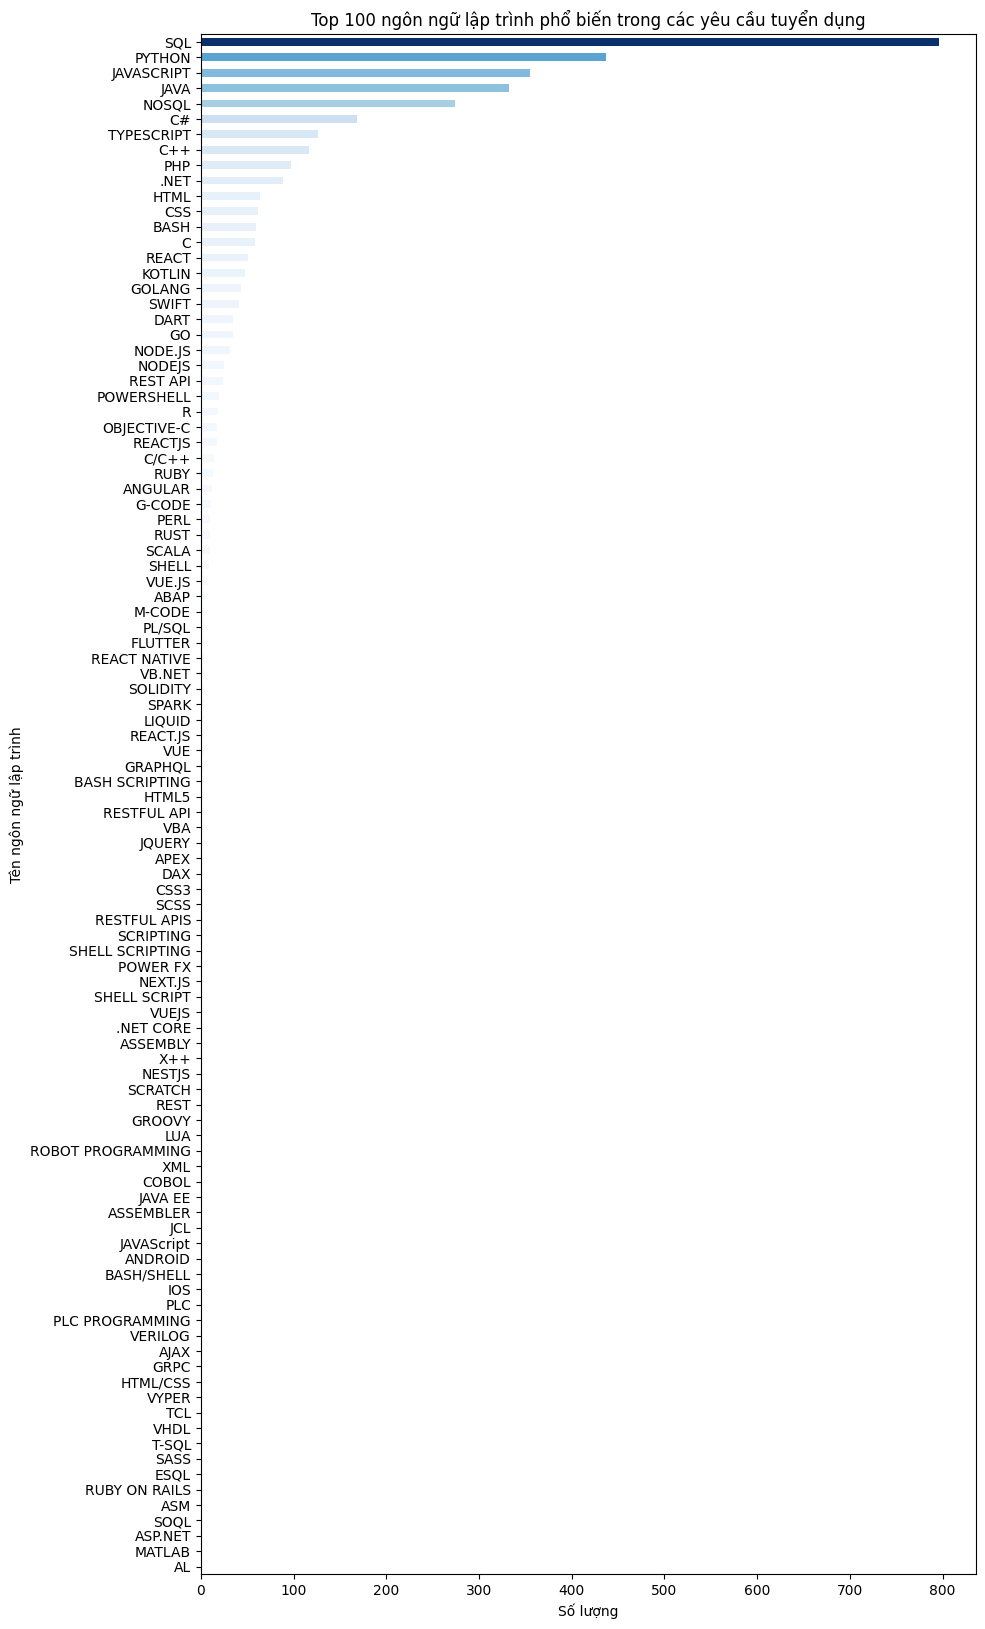

In [ ]:
# Bước 1: Bỏ NaN
df_lang = df_final['Programming_Language'].dropna()

# Bước 2: Chuyển từ chuỗi dạng list → list thực (nếu cần)
df_lang = df_lang.apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Bước 3: Gộp toàn bộ thành list lớn
all_langs = [lang for sublist in df_lang for lang in sublist]

# Bước 4: Đếm
lang_counts = pd.Series(Counter(all_langs)).sort_values(ascending=False)

# Lấy ra 100 Programming_Language phổ biến nhất
top_100_langs = lang_counts.nlargest(100).sort_values(ascending=True)

# Bước 5: Vẽ biểu đồ với thang màu
plt.figure(figsize=(10, 20))  # Điều chỉnh chiều cao để phù hợp với 100 mục

# Tạo thang màu dựa trên giá trị
colors = cm.Blues(top_100_langs / top_100_langs.max())  # Sử dụng thang màu 'Blues'

# Vẽ biểu đồ
top_100_langs.plot(kind='barh', color=colors)
plt.ylabel('Tên ngôn ngữ lập trình')
plt.xlabel('Số lượng')
plt.title('Top 100 ngôn ngữ lập trình phổ biến trong các yêu cầu tuyển dụng')
plt.show()

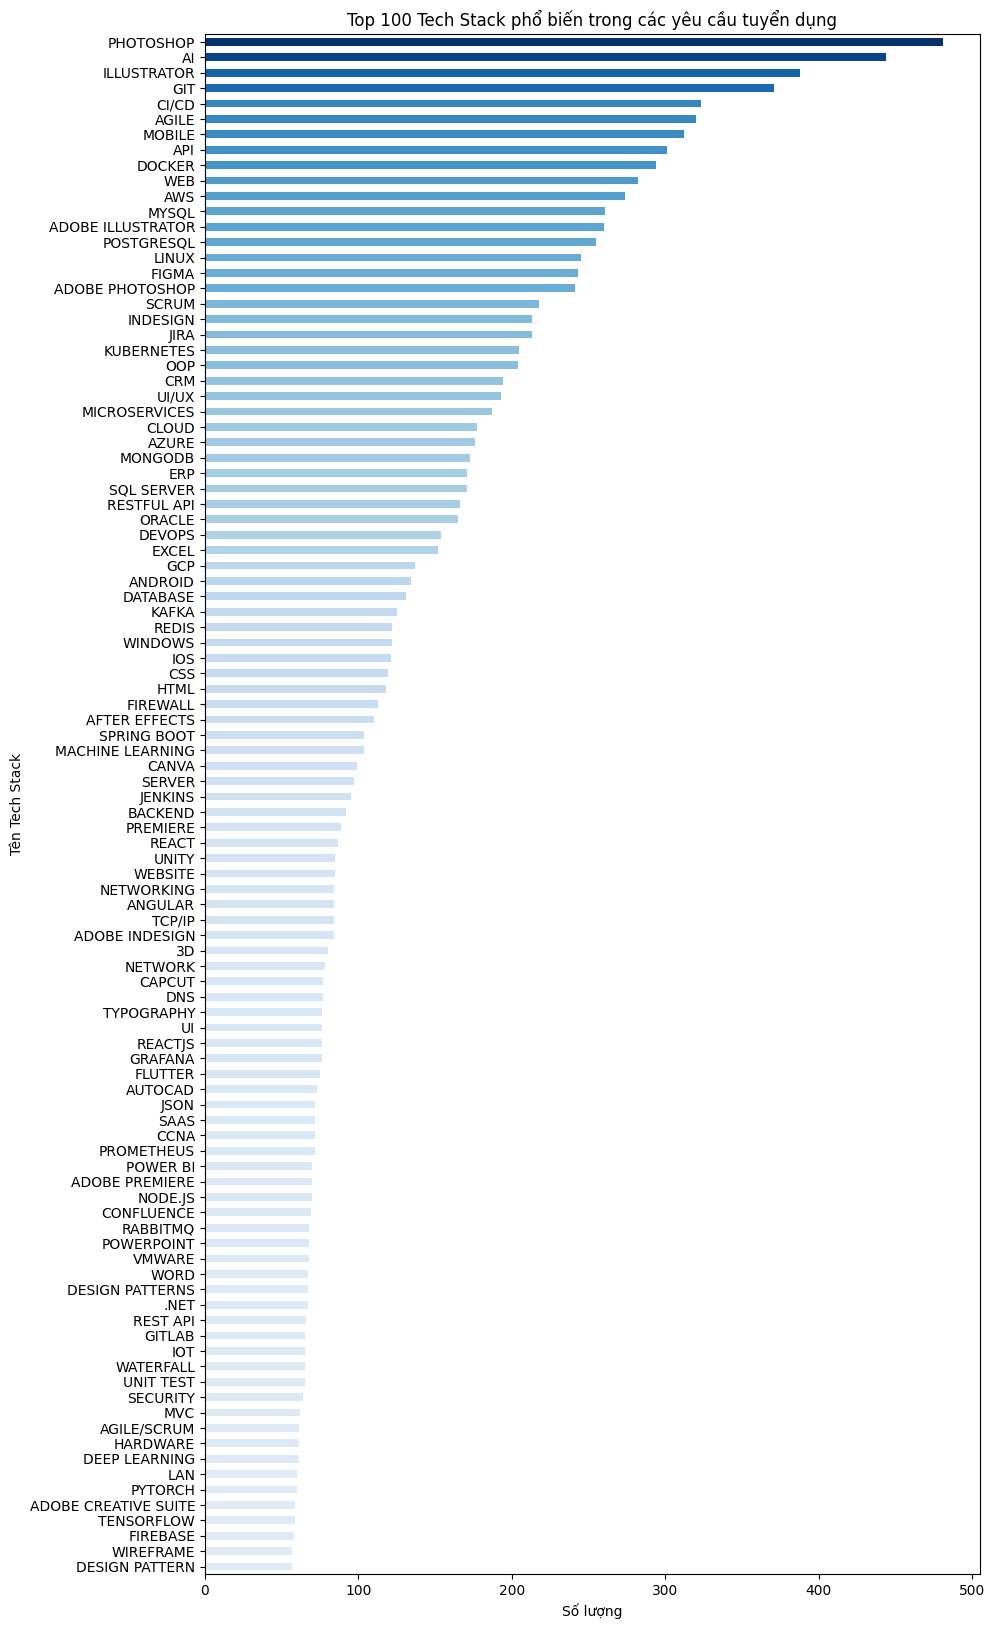

In [ ]:
# Bước 1: Bỏ NaN
df_lang = df_final['Tech_Stack'].dropna()

# Bước 2: Chuyển từ chuỗi dạng list → list thực (nếu cần)
df_lang = df_lang.apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Bước 3: Gộp toàn bộ thành list lớn
all_langs = [lang for sublist in df_lang for lang in sublist]

# Bước 4: Đếm
lang_counts = pd.Series(Counter(all_langs)).sort_values(ascending=False)

# Lấy ra 100 Tech Stack phổ biến nhất
top_100_langs = lang_counts.nlargest(100).sort_values(ascending=True)

# Bước 5: Vẽ biểu đồ với thang màu
plt.figure(figsize=(10, 20))  # Điều chỉnh chiều cao để phù hợp với 100 mục

# Tạo thang màu dựa trên giá trị
colors = cm.Blues(top_100_langs / top_100_langs.max())  # Sử dụng thang màu 'Blues'

# Vẽ biểu đồ
top_100_langs.plot(kind='barh', color=colors)
plt.ylabel('Tên Tech Stack')
plt.xlabel('Số lượng')
plt.title('Top 100 Tech Stack phổ biến trong các yêu cầu tuyển dụng')
plt.show()

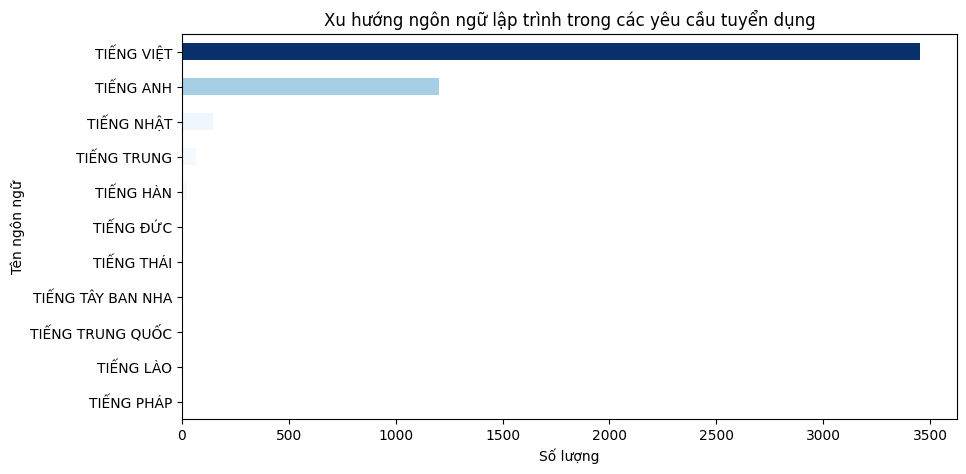

In [ ]:
# Bước 1: Bỏ NaN
df_lang = df_final['Language'].dropna()

# Bước 2: Chuyển từ chuỗi dạng list → list thực (nếu cần)
df_lang = df_lang.apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Bước 3: Gộp toàn bộ thành list lớn
all_langs = [lang for sublist in df_lang for lang in sublist]

# Bước 4: Đếm
lang_counts = pd.Series(Counter(all_langs)).sort_values(ascending=True)

# Bước 5: Vẽ biểu đồ với thang màu
plt.figure(figsize=(10, 5))

# Tạo thang màu dựa trên giá trị
colors = cm.Blues(lang_counts / lang_counts.max())  # Sử dụng thang màu 'Blues'

# Vẽ biểu đồ
lang_counts.plot(kind='barh', color=colors)
plt.ylabel('Tên ngôn ngữ')
plt.xlabel('Số lượng')
plt.title('Xu hướng ngôn ngữ lập trình trong các yêu cầu tuyển dụng')
plt.show()

# Kiểm tra lại bất thường trong dữ liệu ngày đi làm trong tuần 

In [ ]:
df_extracted.head()

,Job_Title,Tech_Stack,Programming_Language,Roles,Recruitment_Count,Province,Company_Location,Current_Employee_Min,Current_Employee_Max,Language,Skills,Total_Work_Hour,Salary_Min,Salary_Max,First_Working_Day_Of_Week,Last_Working_Day_Of_Week,Work_On_Saturday,Work_On_Sunday
0,Product Manager,None,None,"[CÔNG NGHỆ THÔNG TIN, PRODUCT MANAGEMENT, PRODUCT OWNER/PRODUCT MANAGER, VIỆC LÀM IT]",3,[HÀ NỘI],[HÀ NỘI],25.0,99.0,"[TIẾNG VIỆT, TIẾNG ANH]","[TINH THẦN TRÁCH NHIỆM, KỸ NĂNG ĐÀM PHÁN, KỸ NĂNG GIAO TIẾP, CHỊU ĐƯỢC ÁP LỰC CÔNG VIỆC, KỸ NĂNG QUẢN LÝ NHÂN SỰ, KỸ NĂNG HOẠCH ĐỊNH CHIẾN LƯỢC, KỸ NĂNG XÂY DỰNG KẾ HOẠCH, KỸ NĂNG NẮM BẮT THÔNG TIN THỊ TRƯỜNG]",NaN,15000000.0,25000000.0,<NA>,<NA>,None,None
1,Nhân Viên IT Kiêm Tư Vấn & Đào Tạo,"[STEM, ROBOTICS, NETWORKING, ZOOM, WEB ADMINISTRATION, LANDING PAGE, IOT, WORDPRESS, MICROSOFT, GOOGLE, AI]",[HTML],"[CÔNG NGHỆ THÔNG TIN, CÔNG NGHỆ THÔNG TIN KHÁC, CHUYÊN MÔN CÔNG NGHỆ THÔNG TIN KHÁC, VIỆC LÀM IT]",1,[HÀ NỘI],[HÀ NỘI],25.0,99.0,[TIẾNG VIỆT],"[KỸ NĂNG GIAO TIẾP, TƯ VẤN, ĐÀO TẠO, TỔ CHỨC SỰ KIỆN, GIẢNG DẠY, HỖ TRỢ KỸ THUẬT]",45.0,15000000.0,20000000.0,2,6,False,False
2,Nhân Viên Kinh Doanh Phần Mềm Erp/ Sales Erp,"[ERP, CRM, FINANCE, SUPPLY CHAIN]",None,"[KINH DOANH/BÁN HÀNG, CÔNG NGHỆ THÔNG TIN, SALES IT PHẦN MỀM, KINH DOANH PHẦN MỀM, VIỆC LÀM IT]",1,[HỒ CHÍ MINH],[HỒ CHÍ MINH],25.0,99.0,"[TIẾNG VIỆT, TIẾNG TRUNG, TIẾNG ANH]","[XÂY DỰNG MỐI QUAN HỆ, GIAO TIẾP, KỸ NĂNG THUYẾT TRÌNH, KỸ NĂNG ĐÀM PHÁN, ĐỊNH HƯỚNG MỤC TIÊU, CHỊU ĐƯỢC ÁP LỰC, KHẢ NĂNG HỌC HỎI NHANH, PHÂN TÍCH NGHIỆP VỤ]",45.0,30000000.0,60000000.0,2,6,False,False
3,Product Design Leader,"[FINTECH, IOT, FIGMA, ADOBE CREATIVE SUITE, USER-CENTERED DESIGN, AGILE, SCRUM]",None,"[CÔNG NGHỆ THÔNG TIN, THIẾT KẾ, SOFTWARE DESIGN, THIẾT KẾ ĐỒ HOẠ/GIAO DIỆN/TRẢI NGHIỆM, UI/UX DESIGN, VIỆC LÀM IT]",1,[HỒ CHÍ MINH],[HỒ CHÍ MINH],25.0,99.0,"[TIẾNG VIỆT, TIẾNG ANH]","[PRODUCT DESIGN, DESIGN LEADERSHIP, COMPLEX PROBLEM-SOLVING, CREATIVE DIRECTION, TEAM MANAGEMENT, USER-CENTERED DESIGN (UCD), COMMUNICATION, PRESENTATION SKILLS, RECRUITING, BUILDING DESIGN TEAMS, PRODUCT MANAGEMENT, LEADERSHIP, STRATEGY, MENTOR, COACH, PRODUCT THINKING, USER EXPERIENCE, USER INTERFACE, DESIGN SYSTEM]",45.0,NaN,NaN,2,6,False,False
4,AI/Robotics Engineer,"[ROS, NAVIGATION, SLAM, SENSOR FUSION, CONTROL, IMAGE PROCESSING, MACHINE VISION, IMAGE RECOGNITION, MACHINE LEARNING, DEEP LEARNING, OBJECT DETECTION, CLASSIFICATION, SEGMENTATION, AI, ROBOTICS, CAMERA, LIDAR, IMU, OPENCV, TENSORFLOW, PYTORCH, COMPUTER VISION, MOTION PLANNING, NVIDIA JETSON, CUDA, AI ACCELERATION, DOCKER, LINUX, CI/CD, AGV, AMR, ROBOTIC ARMS, GITHUB]","[PYTHON, C++]","[CÔNG NGHỆ THÔNG TIN, ARTIFICIAL INTELLIGENCE (AI), AI ENGINEER, VIỆC LÀM IT]",2,[HỒ CHÍ MINH],[HỒ CHÍ MINH],10.0,24.0,"[TIẾNG VIỆT, TIẾNG ANH]","[TECHNICAL DOCUMENTATION, CODE REVIEWS, COLLABORATION, READ AND UNDERSTAND TECHNICAL DOCUMENTS]",45.0,NaN,NaN,2,6,False,False


In [ ]:
test = pd.read_parquet(r'D:\Python_code\DS111_Final_Term_Project\DS111\analysis-job-trend\data\2-API-processing\API_data_raw.parquet')
check = pd.DataFrame(columns=test.columns)  # Tạo DataFrame rỗng với các cột là các trường trong class Recruiment_Info


In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3458 entries, 0 to 3457
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Job_Title                  3458 non-null   object 
 1   Tech_Stack                 3281 non-null   object 
 2   Programming_Language       1333 non-null   object 
 3   Roles                      3455 non-null   object 
 4   Recruitment_Count          3458 non-null   Int64  
 5   Province                   3457 non-null   object 
 6   Company_Location           3456 non-null   object 
 7   Current_Employee_Min       3299 non-null   float64
 8   Current_Employee_Max       2914 non-null   float64
 9   Language                   3457 non-null   object 
 10  Skills                     3456 non-null   object 
 11  Total_Work_Hour            2952 non-null   float64
 12  Salary_Min                 1842 non-null   float64
 13  Salary_Max                 2101 non-null   float

In [ ]:
test.head(10)

,Job_Title,Tech_Stack,Programming_Language,Roles,Recruitment_Count,Province,Company_Location,Current_Employee_Min,Current_Employee_Max,Language,Skills,Total_Work_Hour,Salary_Min,Salary_Max,First_Working_Day_Of_Week,Last_Working_Day_Of_Week,Work_On_Saturday,Work_On_Sunday,Experience_Years,Deadline,Company_Name,Company_Industry,Job_Level,Academic_Level,Job_Type,Company_URL,Job_URL,Date_Crawl,Layout_Type
0,Product Manager,None,None,"[CÔNG NGHỆ THÔNG TIN, PRODUCT MANAGEMENT, PRODUCT OWNER/PRODUCT MANAGER, VIỆC LÀM IT]",3,[HÀ NỘI],[HÀ NỘI],25.0,99.0,"[TIẾNG VIỆT, TIẾNG ANH]","[TINH THẦN TRÁCH NHIỆM, KỸ NĂNG ĐÀM PHÁN, KỸ NĂNG GIAO TIẾP, CHỊU ĐƯỢC ÁP LỰC CÔNG VIỆC, KỸ NĂNG QUẢN LÝ NHÂN SỰ, KỸ NĂNG HOẠCH ĐỊNH CHIẾN LƯỢC, KỸ NĂNG XÂY DỰNG KẾ HOẠCH, KỸ NĂNG NẮM BẮT THÔNG TIN THỊ TRƯỜNG]",NaN,15000000.0,25000000.0,<NA>,<NA>,NaN,NaN,2 năm,31/01/2026,Công ty Cổ phần Hệ thống Công nghệ ETC,IT - Phần mềm,Nhân viên,Cao Đẳng trở lên,Toàn thời gian,https://www.topcv.vn/cong-ty/cong-ty-co-phan-he-thong-cong-nghe-etc/200939.html,https://www.topcv.vn/viec-lam/ky-su-trien-khai-du-an-he-thong-postsale-system-thu-nhap-upto-40tr/1949543.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807,09/12/2025 13:13:17,standard
1,Nhân Viên IT Kiêm Tư Vấn & Đào Tạo,"[STEM, ROBOTICS, NETWORKING, ZOOM, WEB ADMINISTRATION, LANDING PAGE, IOT, WORDPRESS, MICROSOFT, GOOGLE, AI]",[HTML],"[CÔNG NGHỆ THÔNG TIN, CÔNG NGHỆ THÔNG TIN KHÁC, CHUYÊN MÔN CÔNG NGHỆ THÔNG TIN KHÁC, VIỆC LÀM IT]",1,[HÀ NỘI],[HÀ NỘI],25.0,99.0,[TIẾNG VIỆT],"[KỸ NĂNG GIAO TIẾP, TƯ VẤN, ĐÀO TẠO, TỔ CHỨC SỰ KIỆN, GIẢNG DẠY, HỖ TRỢ KỸ THUẬT]",45.0,15000000.0,20000000.0,2,6,0.0,0.0,Không yêu cầu,02/01/2026,CÔNG TY TNHH CÔNG NGHỆ PHẦN MỀM NASANI,Internet / Online,Nhân viên,Trung cấp trở lên,Toàn thời gian,https://www.topcv.vn/cong-ty/cong-ty-tnhh-cong-nghe-phan-mem-nasani/233549.html,https://www.topcv.vn/viec-lam/nhan-vien-tu-van-phat-trien-phan-mem-hcm-thu-nhap-len-den-25tr-thang/1971777.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807,09/12/2025 13:13:28,standard
2,Nhân Viên Kinh Doanh Phần Mềm Erp/ Sales Erp,"[ERP, CRM, FINANCE, SUPPLY CHAIN]",None,"[KINH DOANH/BÁN HÀNG, CÔNG NGHỆ THÔNG TIN, SALES IT PHẦN MỀM, KINH DOANH PHẦN MỀM, VIỆC LÀM IT]",1,[HỒ CHÍ MINH],[HỒ CHÍ MINH],25.0,99.0,"[TIẾNG VIỆT, TIẾNG TRUNG, TIẾNG ANH]","[XÂY DỰNG MỐI QUAN HỆ, GIAO TIẾP, KỸ NĂNG THUYẾT TRÌNH, KỸ NĂNG ĐÀM PHÁN, ĐỊNH HƯỚNG MỤC TIÊU, CHỊU ĐƯỢC ÁP LỰC, KHẢ NĂNG HỌC HỎI NHANH, PHÂN TÍCH NGHIỆP VỤ]",45.0,30000000.0,60000000.0,2,6,0.0,0.0,Dưới 1 năm,02/01/2026,CÔNG TY CP THIẾT BỊ CÔNG NGHIỆP HUỲNH LONG,Cơ khí,Nhân viên,Trung cấp trở lên,Toàn thời gian,https://www.topcv.vn/cong-ty/cong-ty-cp-thiet-bi-cong-nghiep-huynh-long/105523.html,https://www.topcv.vn/viec-lam/nhan-vien-kinh-doanh-sale-tu-van-ban-hangmay-inluong-cung-12tr-hoa-hong-nhan-viec-ngay/1971328.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807,09/12/2025 13:13:41,standard
3,Product Design Leader,"[FINTECH, IOT, FIGMA, ADOBE CREATIVE SUITE, USER-CENTERED DESIGN, AGILE, SCRUM]",None,"[CÔNG NGHỆ THÔNG TIN, THIẾT KẾ, SOFTWARE DESIGN, THIẾT KẾ ĐỒ HOẠ/GIAO DIỆN/TRẢI NGHIỆM, UI/UX DESIGN, VIỆC LÀM IT]",1,[HỒ CHÍ MINH],[HỒ CHÍ MINH],25.0,99.0,"[TIẾNG VIỆT, TIẾNG ANH]","[PRODUCT DESIGN, DESIGN LEADERSHIP, COMPLEX PROBLEM-SOLVING, CREATIVE DIRECTION, TEAM MANAGEMENT, USER-CENTERED DESIGN (UCD), COMMUNICATION, PRESENTATION SKILLS, RECRUITING, BUILDING DESIGN TEAMS, PRODUCT MANAGEMENT, LEADERSHIP, STRATEGY, MENTOR, COACH, PRODUCT THINKING, USER EXPERIENCE, USER INTERFACE, DESIGN SYSTEM]",45.0,NaN,NaN,2,6,0.0,0.0,3 năm,27/12/2025,CÔNG TY CỔ PHẦN CÔNG NGHỆ THÔNG MINH GX,IT - Phần mềm,Nhân viên,Đại Học trở lên,Toàn thời gian,https://www.topcv.vn/cong-ty/cong-ty-co-phan-cong-nghe-thong-minh-gx/243568.html,https://www.topcv.vn/viec-lam/business-analyst-tu-3-nam-kinh-nghiem-thu-nhap-upto-30m-tai-ha-noi/1966948.html?ta_source=JobSearch

In [ ]:
#Hiển thị max số lượng cột 
pd.set_option('display.max_columns', None)

In [ ]:
test[['Total_Work_Hour', 'Job_URL']].head(100)

,Total_Work_Hour,Job_URL
0,NaN,https://www.topcv.vn/viec-lam/ky-su-trien-khai-du-an-he-thong-postsale-system-thu-nhap-upto-40tr/1949543.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
1,45.000000,https://www.topcv.vn/viec-lam/nhan-vien-tu-van-phat-trien-phan-mem-hcm-thu-nhap-len-den-25tr-thang/1971777.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
2,45.000000,https://www.topcv.vn/viec-lam/nhan-vien-kinh-doanh-sale-tu-van-ban-hangmay-inluong-cung-12tr-hoa-hong-nhan-viec-ngay/1971328.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
3,45.000000,https://www.topcv.vn/viec-lam/business-analyst-tu-3-nam-kinh-nghiem-thu-nhap-upto-30m-tai-ha-noi/1966948.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
4,45.000000,https://www.topcv.vn/viec-lam/nhan-vien-kinh-doanh-phan-mem-erp-sales-erp-thu-nhap-cao-upto-30-60-trieu-nhan-viec-ngay-tai-quan-7/1891406.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
5,NaN,https://www.topcv.vn/viec-lam/ai-robotics-engineer/1974897.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
6,50.000000,https://www.topcv.vn/viec-lam/network-engineer-trien-khai/1975191.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
7,45.000000,https://www.topcv.vn/viec-lam/intern-qc-japanese-n4/1967453.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
8,54.000000,https://www.topcv.vn/viec-lam/product-manager/1969894.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
9,49.000000,https://www.topcv.vn/viec-lam/nhan-vien-kinh-doanh-cntt/1973321.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807


## Kiểm tra miền giá trị của các thuộc tính ngày đi làm trong tuần


In [ ]:
unique_first_working_days = test['First_Working_Day_Of_Week'].unique().tolist()
unique_last_working_days = test['Last_Working_Day_Of_Week'].unique().tolist()

print("Unique values of First_Working_Day_Of_Week:", unique_first_working_days)
print("Unique values of Last_Working_Day_Of_Week:", unique_last_working_days)

Unique values of First_Working_Day_Of_Week: [<NA>, 2, 3]
Unique values of Last_Working_Day_Of_Week: [<NA>, 6, 4]


In [ ]:
#Kiểm tra các mẫu bất thường về ngày đi làm trong tuần
# test = df_extracted.copy() # Tạo bản sao của DataFrame đã trích xuất thông tin
# check = pd.DataFrame(columns=test.columns)  
# Kiểm tra nếu 'job_title' chứa một trong hai từ khóa "Triệu" hoặc "lương"
for i in range(len(test)):
    # if pd.notna(test.iloc[i]['job_title']) and any(keyword in test.iloc[i]['job_title'] for keyword in ['Triệu', 'Lương', 'Tiếng']):
    #     print(f"Row {i} contains 'Triệu' or 'Lương' in 'job_title':")
    if (pd.isna(test.iloc[i]['First_Working_Day_Of_Week']) and pd.notna(test.iloc[i]['Last_Working_Day_Of_Week'])) or (
        pd.notna(test.iloc[i]['First_Working_Day_Of_Week']) and (test.iloc[i]['First_Working_Day_Of_Week'] != 2)) or (
        (pd.notna(test.iloc[i]['First_Working_Day_Of_Week']) and pd.isna(test.iloc[i]['Last_Working_Day_Of_Week']))) or(
            pd.notna(test.iloc[i]['Last_Working_Day_Of_Week']) and (test.iloc[i]['Last_Working_Day_Of_Week'] != 6) or (
                test.iloc[i]['Work_On_Sunday'] == 1)
        ):
        check.loc[len(check)] = test.iloc[i]


## Các mẫu bất thường về thời gian làm việc trong tuần trong dữ liệu 

In [ ]:
test[test['Work_On_Saturday']==1][['First_Working_Day_Of_Week','Last_Working_Day_Of_Week','Work_On_Saturday','Work_On_Sunday', 'Job_URL']].head(200)

,First_Working_Day_Of_Week,Last_Working_Day_Of_Week,Work_On_Saturday,Work_On_Sunday,Job_URL
8,2,6,1.0,0.0,https://www.topcv.vn/viec-lam/product-manager/1969894.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
9,2,6,1.0,0.0,https://www.topcv.vn/viec-lam/nhan-vien-kinh-doanh-cntt/1973321.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
10,2,6,1.0,0.0,https://www.topcv.vn/viec-lam/nhan-vien-gan-nhan-kiem-duyet-noi-dung-san-thuong-mai-dien-tu-mang-cham-soc-khach-hang-thu-nhap-8-trieu-thang-quan-12-di-lam-ngay/1968880.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
12,2,6,1.0,0.0,https://www.topcv.vn/viec-lam/senior-frontend-developer-react-js-next-js-muc-luong-upto-30m/1967715.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
15,<NA>,<NA>,1.0,1.0,https://www.topcv.vn/viec-lam/product-design-leader/1972888.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
17,2,6,1.0,0.0,https://www.topcv.vn/viec-lam/chuyen-vien-cong-nghe-thong-tin-chuyen-doi-so-thu-nhap-15-20-trieu-tai-bac-ninh/1964069.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
22,2,6,1.0,0.0,https://www.topcv.vn/viec-lam/manual-testers/1972856.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
31,2,6,1.0,0.0,https://www.topcv.vn/viec-lam/production-lead-visual-supervisor-vve/1970074.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
32,2,6,1.0,0.0,https://www.topcv.vn/viec-lam/visual-producer-project-manager-korean-speaking/1970305.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
33,2,6,1.0,0.0,https://www.topcv.vn/viec-lam/net-developer/1907652.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807


In [ ]:
# Kiểm tra có bao nhiêu cột Work_On_Sunday = 1
test[test['Work_On_Saturday']==1].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1307 entries, 8 to 3457
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Job_Title                  1307 non-null   object 
 1   Tech_Stack                 1223 non-null   object 
 2   Programming_Language       323 non-null    object 
 3   Roles                      1306 non-null   object 
 4   Recruitment_Count          1307 non-null   Int64  
 5   Province                   1307 non-null   object 
 6   Company_Location           1307 non-null   object 
 7   Current_Employee_Min       1251 non-null   float64
 8   Current_Employee_Max       1131 non-null   float64
 9   Language                   1307 non-null   object 
 10  Skills                     1307 non-null   object 
 11  Total_Work_Hour            1113 non-null   float64
 12  Salary_Min                 915 non-null    float64
 13  Salary_Max                 958 non-null    float64
 1

In [ ]:
check

,Job_Title,Tech_Stack,Programming_Language,Roles,Recruitment_Count,Province,Company_Location,Current_Employee_Min,Current_Employee_Max,Language,Skills,Total_Work_Hour,Salary_Min,Salary_Max,First_Working_Day_Of_Week,Last_Working_Day_Of_Week,Work_On_Saturday,Work_On_Sunday,Experience_Years,Deadline,Company_Name,Company_Industry,Job_Level,Academic_Level,Job_Type,Company_URL,Job_URL,Date_Crawl,Layout_Type
0,Nhân Viên Gán Nhãn & Kiểm Duyệt Nội Dung Sàn Thương Mại Điện Tử (Mảng Chăm Sóc Khách Hàng),"[ARTIFICIAL INTELLIGENCE, DATA LABELING]",None,"[CHĂM SÓC KHÁCH HÀNG, CÔNG NGHỆ THÔNG TIN, BUSINESS OPERATION, ARTIFICIAL INTELLIGENCE, DATA LABELING, VIỆC LÀM IT]",10,[HỒ CHÍ MINH],[HỒ CHÍ MINH],10.0,24.0,"[TIẾNG VIỆT, TIẾNG ANH]","[TIẾNG ANH, TỐC ĐỘ ĐÁNH MÁY, KỸ NĂNG GIAO TIẾP, XỬ LÝ TÌNH HUỐNG, CHĂM SÓC KHÁCH HÀNG, SỬ DỤNG MÁY TÍNH, PHÂN TÍCH THÔNG TIN]",37.5,7400000.0,8000000.0,NaN,NaN,1.0,1.0,5 năm,02/01/2026,VĂN PHÒNG ĐẠI DIỆN STYL SOLUTIONS PTE. LTD. TẠI THÀNH PHỐ HỒ CHÍ MINH,IT - Phần mềm,Trưởng nhóm,Đại Học trở lên,Toàn thời gian,https://www.topcv.vn/cong-ty/van-phong-dai-dien-styl-solutions-pte-ltd-tai-thanh-pho-ho-chi-minh/95267.html,https://www.topcv.vn/viec-lam/product-design-leader/1972888.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807,09/12/2025 13:16:19,standard
1,Giáo Viên Lập Trình,"[ROBOTICS, UNITY, MINECRAFT MODDING, SCRATCH, ROBLOX SCRIPTING]","[PYTHON, C++]","[GIÁO DỤC/ĐÀO TẠO, GIÁO VIÊN/GIẢNG VIÊN/GIA SƯ, GIÁO VIÊN TIN HỌC]",1,[HỒ CHÍ MINH],[HỒ CHÍ MINH],100.0,499.0,[TIẾNG VIỆT],"[KỸ NĂNG GIAO TIẾP, KỸ NĂNG THUYẾT TRÌNH, KỸ NĂNG NGHIÊN CỨU, GIẢNG DẠY, SƯ PHẠM, QUẢN LÝ LỚP HỌC, KIÊN NHẪN, TRUYỀN ĐẠT KIẾN THỨC]",28.0,NaN,NaN,NaN,NaN,1.0,1.0,2 năm,02/01/2026,Công ty Cổ phần MISA,IT - Phần mềm,Nhân viên,Đại Học trở lên,Toàn thời gian,https://www.topcv.vn/cong-ty/cong-ty-co-phan-misa/198409.html,https://www.topcv.vn/viec-lam/business-analyst-lending-bankhub/1972353.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095820,09/12/2025 13:34:05,standard
2,Customer Service (N1/N2 Japanese),[LOG ANALYSIS],None,"[CÔNG NGHỆ THÔNG TIN, IT INFRASTRUCTURE AND OPERATIONS, IT HELPDESK/IT SUPPORT, VIỆC LÀM IT]",2,[HỒ CHÍ MINH],[HỒ CHÍ MINH],500.0,1000.0,"[TIẾNG VIỆT, TIẾNG NHẬT, TIẾNG ANH]","[JAPANESE PROFICIENCY, ENGLISH TECHNICAL DOCUMENT COMPREHENSION, CUSTOMER SERVICE MINDSET, TROUBLESHOOTING, PROBLEM-SOLVING, COLLABORATION]",45.0,20000000.0,30000000.0,NaN,NaN,1.0,1.0,2 năm,24/12/2025,Công ty Cổ phần MISA,IT - Phần mềm,Nhân viên,Cao Đẳng trở lên,Toàn thời gian,https://www.topcv.vn/cong-ty/cong-ty-co-phan-misa/198409.html,https://www.topcv.vn/viec-lam/lap-trinh-vien-flutter-ios/1962014.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095820,09/12/2025 13:35:55,standard
3,Trưởng Nhóm Học Thuật Về Lập Trình/ Coding Academic Leader,"[ROBOTICS, UNITY, MINECRAFT MODDING, SCRATCH, ROBLOX SCRIPTING]","[PYTHON, C++]","[GIÁO DỤC/ĐÀO TẠO, QUẢN LÝ GIÁO DỤC, QUẢN LÝ CHẤT LƯỢNG GIÁO DỤC]",1,[HỒ CHÍ MINH],[HỒ CHÍ MINH],100.0,499.0,[TIẾNG VIỆT],"[KỸ NĂNG GIAO TIẾP, KỸ NĂNG THUYẾT TRÌNH, KỸ NĂNG NGHIÊN CỨU, KỸ NĂNG SƯ PHẠM, GIẢNG DẠY LẬP TRÌNH, KIẾN THỨC VỀ LẬP TRÌNH VÀ KHOA HỌC MÁY TÍNH, QUẢN LÝ LỚP HỌC]",48.0,12000000.0,13000000.0,2,6,1.0,1.0,Không yêu cầu,05/01/2026,CÔNG TY TNHH TMDV CÔNG NGHỆ VPS,Null,Nhân viên,Trung cấp trở lên,Toàn thời gian,https://www.topcv.vn/brand/congnghevps?id=138912,https://www.topcv.vn/brand/congnghevps/tuyen-dung/nhan-vien-tu-van-phan-mem-khong-kinh-nghiem-luong-upto-30-trieu-j1531339.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095820,09/12/2025 13:36:19,brand_v1
4,Giáo Viên Lập Trình - Part-Time,"[UNITY, MINECRAFT, SCRATCH, ROBLOX, ROBOTICS]","[PYTHON, C++]","[GIÁO DỤC/ĐÀO TẠO, VĂN HOÁ/NGHỆ THUẬT/KHOA HỌC, GIÁO VIÊN STEAM/STEM]",1,[HỒ CHÍ MINH],[HỒ CHÍ MINH],100.0,499.0,[TIẾNG VIỆT],"[KỸ NĂNG GIAO TIẾP, KỸ NĂNG THUYẾT TRÌNH, KỸ 

## Đường link dẫn tới các thông tin tuyển dụng trong mục kiểm tra bất thường trong dữ liệu (biến check) 

In [ ]:
list_bad_url = check['Job_URL'].tolist() # Lấy danh sách các URL từ DataFrame
list_bad_url

['https://www.topcv.vn/viec-lam/product-design-leader/1972888.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807',
 'https://www.topcv.vn/viec-lam/business-analyst-lending-bankhub/1972353.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095820',
 'https://www.topcv.vn/viec-lam/lap-trinh-vien-flutter-ios/1962014.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095820',
 'https://www.topcv.vn/brand/congnghevps/tuyen-dung/nhan-vien-tu-van-phan-mem-khong-kinh-nghiem-luong-upto-30-trieu-j1531339.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095820',
 'https://www.topcv.vn/viec-lam/playable-ads-upto-17m/1974587.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095842',
 'https://www.topcv.vn/viec-lam/ho-tro-ky-thuat-truc-ca/1697469.html?ta_source=JobSearchList_LinkDeta

In [ ]:
# fixed_samples = pd.DataFrame(columns=data_copy.columns)  # Tạo DataFrame rỗng với các cột là các trường trong class Recruiment_Info
# for i in range(len(data_copy)):
#     if data_copy.iloc[i]['URL'] in list_bad_url:
#         time.sleep(2.5) 
#         data_processed = extract_info(data_original.iloc[i], GOOGLE_API_KEY[len(GOOGLE_API_KEY) - 1]) # Gọi lại hàm extract_info với các dòng dữ liệu có URL trong danh sách list_bad_url
#         if data_processed:  # Kiểm tra nếu data_processed không phải None
#             # Cập nhật trực tiếp các cột trong data_copy
#             data_copy.at[i, 'job_title'] = data_processed['job_title']
#             data_copy.at[i, 'Tech_Stack'] = data_processed['Tech_Stack']
#             data_copy.at[i, 'Programming_Language'] = data_processed['Programming_Language']
#             data_copy.at[i, 'First_Working_Day_Of_Week'] = data_processed['First_Working_Day_Of_Week']
#             data_copy.at[i, 'Last_Working_Day_Of_Week'] = data_processed['Last_Working_Day_Of_Week']
#             data_copy.at[i, 'Work_On_Saturday'] = data_processed['Work_On_Saturday']
#             data_copy.at[i, 'Work_On_Sunday'] = data_processed['Work_On_Sunday']
#             data_copy.at[i, 'Total_Work_Hour'] = data_processed['Total_Work_Hour']
#             data_copy.at[i, 'Province'] = data_processed['Province']
#             data_copy.at[i, 'Salary_Min'] = data_processed['Salary_Min']
#             data_copy.at[i, 'Salary_Max'] = data_processed['Salary_Max']
#             data_copy.at[i, 'Recruitment_Count'] = data_processed['Recruitment_Count']
#             data_copy.at[i, 'Language'] = data_processed['Language']
#         fixed_samples.loc[len(fixed_samples)] = data_copy.iloc[i] # Thêm dòng dữ liệu đã sửa vào DataFrame fixed_samples

In [ ]:
# fixed_samples

In [ ]:
# data_copy['Work_On_Saturday'] = data_copy['Work_On_Saturday'].astype(bool)
# data_copy['Work_On_Sunday'] = data_copy['Work_On_Sunday'].astype(bool)
# data_copy.info()